In this script, we will:

* calculate the Top of the Atmosphere (TOA) Radiative Imbalance in the x4CO2 forcing scenario,

* calculate the Atmosphere and Ocean heat transports and their change during time and

* explore an alternative way of assesing Bjerknes Compensation.

***This script uses data specifically from the NorESM2-LM and IPSL-CM6A-LR models.**

The data used have been downloaded from the [esgf](https://aims2.llnl.gov/search) base and have been used in my personal account on vann.


**we apply a correction to the HT so that they go to 0 at the NH, in order to avoid cumulative errors and to focus just n the HT.**

### **0.1. Importing packages and functions**

In [2]:
# For skiping running a certain cell
from IPython.core.magic import register_cell_magic
@register_cell_magic
def comment(line, cell):
    return
    
# The functions we made in separate modules (including some more packages as well)
import sys
sys.path.append('/home/chrikap/Desktop/atmospheric_heat_transport/heat_transport_datasets/Annual_Variations/CMIP6/Paper_Scripts/GitHub_final_scripts/local_functions')

from long_CMIP6_functions_local import *

# Reloading the module automatically, even though we might have changed it
%reload_ext autoreload
%autoreload 2

#import dask

In [2]:
experiments = ['piControl', 'x4CO2']

# The different heat fluxes needed for each realm:  
components_atm = ['rlut', 'rsdt', 'rsut', 'hfls', 'hfss', 'rlds', 'rlus', 'rsds', 'rsus']

# The ocean heat transport
components_ocean = ['hfbasin']

models = ['NorESM2-LM', 'IPSL-CM6A-LR']

## **Part 1: The TOA Radiative Imbalance**

### **1.1. NorESM2-LM**

### **Part A: y0-500**

#### **1. Calculating the atmopsheric fluxes**

In [34]:
# Choosing the time period

num_y = 500 # the number of years I'm working with when I'm not using time average

atm_fluxes_noresm2, lon_noresm2, lat_noresm2 = atm_fluxes_fnc('NorESM2-LM', 0, 500*12, experiments, components_atm)

#### **2. Creating arrays with the atm. fl. values**

In [4]:
# Assigning names to each flux 
for i, name in enumerate(components_atm):
    globals()[f"{name}_noresm2_piControl"] = atm_fluxes_noresm2[0][i]
    globals()[f"{name}_noresm2_x4CO2"] = atm_fluxes_noresm2[1][i]

# Calculating the zonal average of each heat flux
for i, name in enumerate(components_atm):
    globals()[f"{name}_zon_noresm2_piControl"] = np.mean(atm_fluxes_noresm2[0][i], axis=-1)
    globals()[f"{name}_zon_noresm2_x4CO2"] = np.mean(atm_fluxes_noresm2[1][i], axis=-1)

#### **3. Calculating and plotting the Global and Hemispheric Imbalance**

In [ ]:
glb_imb_noresm2, nh_imb_noresm2, sh_imb_noresm2  = imbalance('NorESM2-LM', rsdt_noresm2_x4CO2, rlut_noresm2_x4CO2, rsut_noresm2_x4CO2)

In [6]:
glb_imb_noresm2_pi, nh_imb_noresm2_pi, sh_imb_noresm2_pi  = imbalance('NorESM2-LM', rsdt_noresm2_piControl, rlut_noresm2_piControl, rsut_noresm2_piControl)

In [29]:
save_dir = '/home/chrikap/Desktop/atmospheric_heat_transport/heat_transport_datasets/Annual_Variations/CMIP6/Paper_Scripts/GitHub_final_scripts/local_data/long_scale_noresm2_lm')

#f_atm_fluxes_noresm2 = f"{save_dir}/atm_fluxes_noresm2.npy"
#f_lat_noresm2 = f"{save_dir}/lat_noresm2.npy"
#f_lon_noresm2 = f"{save_dir}/lon_noresm2.npy"

f_glb_imb_noresm2 = f"{save_dir}/glb_imb_noresm2.npy"
f_nh_imb_noresm2 = f"{save_dir}/nh_imb_noresm2.npy"
f_sh_imb_noresm2 = f"{save_dir}/sh_imb_noresm2.npy"

np.save(f_atm_fluxes_noresm2, atm_fluxes_noresm2)
np.save(f_lat_noresm2, lat_noresm2)
np.save(f_lon_noresm2, lon_noresm2)

np.save(f_glb_imb_noresm2, glb_imb_noresm2)
np.save(f_nh_imb_noresm2, nh_imb_noresm2)
np.save(f_sh_imb_noresm2, sh_imb_noresm2)

#### **4. Rolling mean and plotting**

In [4]:
load_dir = '/home/chrikap/Desktop/atmospheric_heat_transport/heat_transport_datasets/Annual_Variations/CMIP6/Paper_Scripts/GitHub_final_scripts/local_data/long_scale_noresm2_lm'

atm_fluxes_noresm2 = np.load(f'{load_dir}/atm_fluxes_noresm2.npy')
lat_noresm2 = np.load(f'{load_dir}/lat_noresm2.npy')
lon_noresm2 = np.load(f'{load_dir}/lon_noresm2.npy')
glb_imb_noresm2 = np.load(f'{load_dir}/glb_imb_noresm2.npy')
nh_imb_noresm2 = np.load(f'{load_dir}/nh_imb_noresm2.npy')
sh_imb_noresm2 = np.load(f'{load_dir}/sh_imb_noresm2.npy')

In [5]:
roll_glb_imb_noresm2 = rolling_average_ts(glb_imb_noresm2, 11)
roll_nh_imb_noresm2 = rolling_average_ts(nh_imb_noresm2, 11)
roll_sh_imb_noresm2 = rolling_average_ts(sh_imb_noresm2, 11)

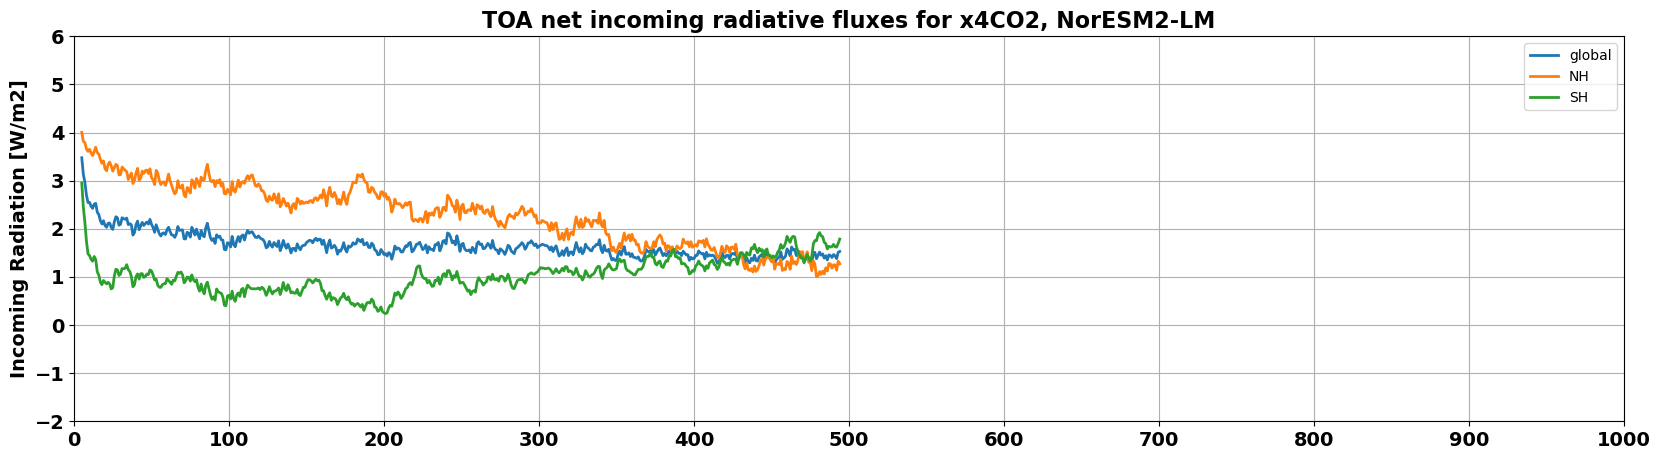

In [8]:
#%%commment
time = np.arange(0, 500)
time_roll = np.arange(5, 495) # we assigne the mean value to the middle point

plt.figure(figsize=(20, 5))

#plt.plot(time, glb_imb_noresm2, color = 'tab:blue', alpha = 0.5, label = 'global')
plt.plot(time_roll, roll_glb_imb_noresm2, color = 'tab:blue', linewidth = 2, label = 'global')

#plt.plot(time, nh_imb_noresm2, color = 'tab:orange', alpha = 0.5, label = 'NH')
plt.plot(time_roll, roll_nh_imb_noresm2, color = 'tab:orange', linewidth = 2, label = 'NH')

#plt.plot(time, sh_imb_noresm2, color = 'tab:green', alpha = 0.5, label = 'SH')
plt.plot(time_roll, roll_sh_imb_noresm2, color = 'tab:green', linewidth =2, label = 'SH')
plt.xlim(0, 1000)
plt.ylim(-2, 6)

#plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('Incoming Radiation [W/m2]', fontsize=14, fontweight='bold')
plt.title('TOA net incoming radiative fluxes for x4CO2, NorESM2-LM', fontsize=16, fontweight='bold')

plt.xticks(np.arange(0, 1001, 100), fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

plt.legend()
plt.grid()

### **Part B: y500-600(620)**

#### **1. Getting the data from the NIRD path: /projects/NS9560K/noresm/cases/NCO2x4_f19_tn14_20191129/atm/hist/**

*we apply the rolling average for timeseries from the BJC_functions file

In [11]:
path = '/home/chrikap/Desktop/atmospheric_heat_transport/heat_transport_datasets/Annual_Variations/CMIP6/Paper_Scripts/GitHub_final_scripts/local_data/long_scale_noresm2_lm/600y_noresm'
FSNT = xr.open_dataset(f'{path}/FSNT.nc') # net incoming shortwave radiation
FLNT = xr.open_dataset(f'{path}/FLNT.nc') # net outgoing longwave radiation

In [12]:
NET = (yearly_avg(FSNT['FSNT']) - yearly_avg(FLNT['FLNT'])).to_dataset(name = "restom") # y500-620
NET_500_600 = NET.isel(year = slice(0, 100))                                            # y500-600

#### **2. Calcualting the radiative imbalance for up to 600 and up to 620 years**

In [13]:
# all

sh_500_620 = NET.sel(lat=slice(None,0)) 

nh_500_620 = NET.sel(lat=slice(0,None))
    
sh_imb_500_620 = areaavg(sh_500_620, 'restom')
nh_imb_500_620 = areaavg(nh_500_620, 'restom')
    
glb_imb_500_620 = areaavg(NET, 'restom')

# Connecting with the rest 
glb_imb_noresm2_all = np.concatenate((glb_imb_noresm2, glb_imb_500_620.values))
nh_imb_noresm2_all = np.concatenate((nh_imb_noresm2, nh_imb_500_620.values))
sh_imb_noresm2_all = np.concatenate((sh_imb_noresm2, sh_imb_500_620.values))

# and THEN rolling mean
roll_glb_imb_noresm2_all = rolling_average_ts(glb_imb_noresm2_all, 11)
roll_nh_imb_noresm2_all = rolling_average_ts(nh_imb_noresm2_all, 11)
roll_sh_imb_noresm2_all = rolling_average_ts(sh_imb_noresm2_all, 11)

In [14]:
# 500-600
sh_500_600 = NET_500_600.sel(lat=slice(None,0)) 

nh_500_600 = NET_500_600.sel(lat=slice(0,None))
    
sh_imb_500_600 = areaavg(sh_500_600, 'restom')
nh_imb_500_600 = areaavg(nh_500_600, 'restom')
    
glb_imb_500_600 = areaavg(NET_500_600, 'restom')

# Just up to y 600

# Connecting with the rest and THEN rolling mean
glb_imb_noresm2_600 = np.concatenate((glb_imb_noresm2, glb_imb_500_600.values))
nh_imb_noresm2_600 = np.concatenate((nh_imb_noresm2, nh_imb_500_600.values))
sh_imb_noresm2_600 = np.concatenate((sh_imb_noresm2, sh_imb_500_600.values))

roll_glb_imb_noresm2_600 = rolling_average_ts(glb_imb_noresm2_600, 11)
roll_nh_imb_noresm2_600 = rolling_average_ts(nh_imb_noresm2_600, 11)
roll_sh_imb_noresm2_600 = rolling_average_ts(sh_imb_noresm2_600, 11)

#### **3. Plotting (up to 600 and up to 620 years)**

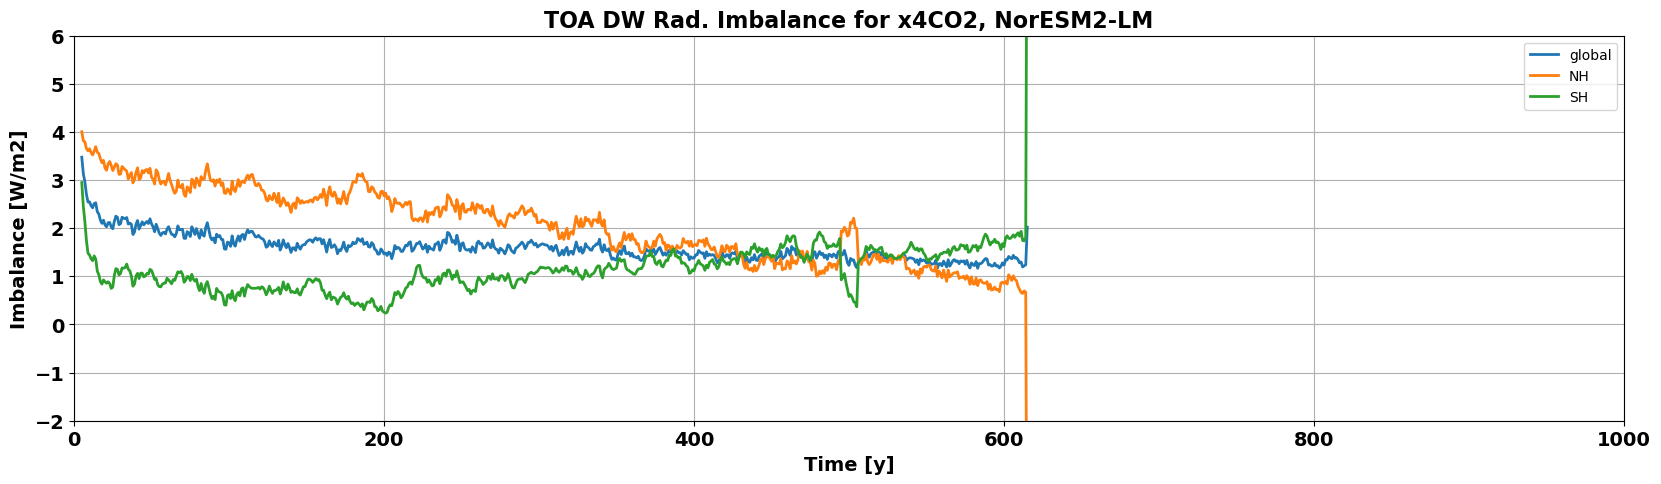

In [25]:
#%%commment
time_roll = np.arange(5, 616) # we assigne the mean value to the middle point

plt.figure(figsize=(20, 5))

#plt.plot(time, glb_imb_noresm2, color = 'tab:blue', alpha = 0.5, label = 'global')
plt.plot(time_roll, roll_glb_imb_noresm2_all, color = 'tab:blue', linewidth = 2, label = 'global')

#plt.plot(time, nh_imb_noresm2, color = 'tab:orange', alpha = 0.5, label = 'NH')
plt.plot(time_roll, roll_nh_imb_noresm2_all, color = 'tab:orange', linewidth = 2, label = 'NH')

#plt.plot(time, sh_imb_noresm2, color = 'tab:green', alpha = 0.5, label = 'SH')
plt.plot(time_roll, roll_sh_imb_noresm2_all, color = 'tab:green', linewidth =2, label = 'SH')
plt.xlim(0, 1000)
plt.ylim(-2, 6)

plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('Imbalance [W/m2]', fontsize=14, fontweight='bold')
plt.title('TOA DW Rad. Imbalance for x4CO2, NorESM2-LM', fontsize=16, fontweight='bold')

plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

plt.legend()
plt.grid()

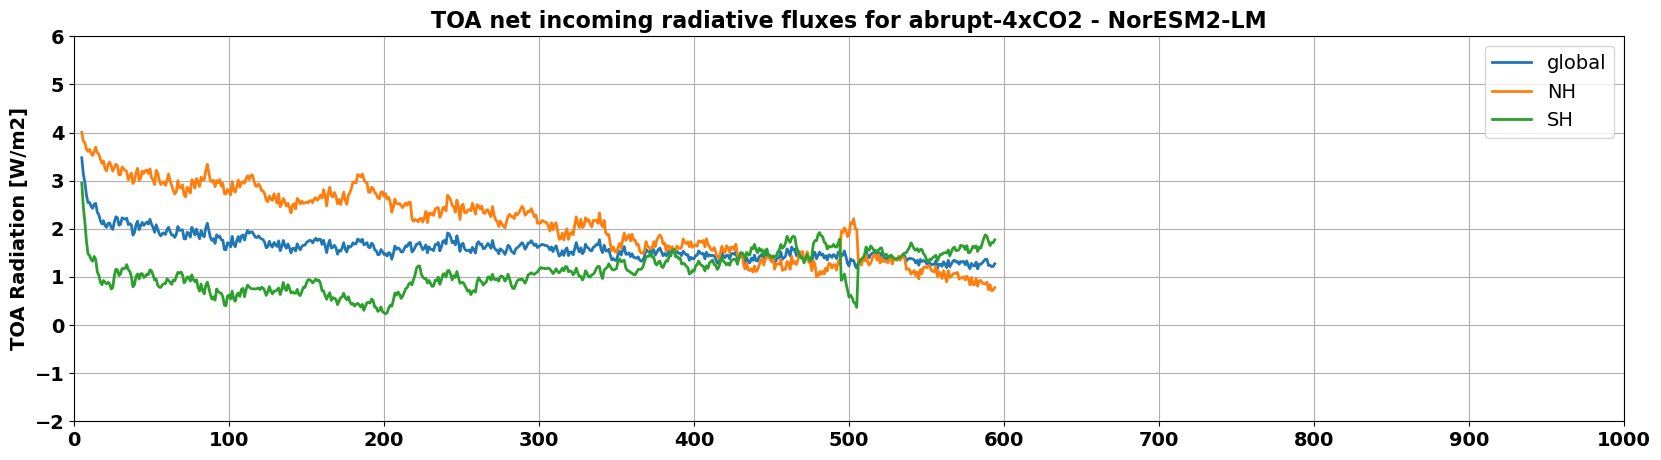

In [25]:
#%%commment
time_roll = np.arange(5, 595) # we assigne the mean value to the middle point

plt.figure(figsize=(20, 5))

#plt.plot(time, glb_imb_noresm2, color = 'tab:blue', alpha = 0.5, label = 'global')
plt.plot(time_roll, roll_glb_imb_noresm2_600, color = 'tab:blue', linewidth = 2, label = 'global')

#plt.plot(time, nh_imb_noresm2, color = 'tab:orange', alpha = 0.5, label = 'NH')
plt.plot(time_roll, roll_nh_imb_noresm2_600, color = 'tab:orange', linewidth = 2, label = 'NH')

#plt.plot(time, sh_imb_noresm2, color = 'tab:green', alpha = 0.5, label = 'SH')
plt.plot(time_roll, roll_sh_imb_noresm2_600, color = 'tab:green', linewidth =2, label = 'SH')
plt.xlim(0, 1000)
plt.ylim(-2, 6)

#plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('TOA Radiation [W/m2]', fontsize=14, fontweight='bold')
plt.title('TOA net incoming radiative fluxes for abrupt-4xCO2 - NorESM2-LM', fontsize=16, fontweight='bold')

plt.xticks(np.arange(0, 1001, 100), fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')

plt.legend(fontsize=14)
plt.grid()

### **1.2. IPSL-CM6A-LR**

#### **1. Calculating the atmopsheric fluxes**

In [5]:
atm_fluxes_ipsl, lon_ipsl, lat_ipsl = atm_fluxes_fnc('IPSL-CM6A-LR', 0, 900*12, experiments, components_atm)

#### **2. Creating arrays with the atm. fl. values**

In [6]:
# Assigning names to each flux 
for i, name in enumerate(components_atm):
    globals()[f"{name}_ipsl_piControl"] = atm_fluxes_ipsl[0][i]
    globals()[f"{name}_ipsl_x4CO2"] = atm_fluxes_ipsl[1][i]

# Calculating the zonal average of each heat flux
for i, name in enumerate(components_atm):
    globals()[f"{name}_zon_ipsl_piControl"] = np.mean(atm_fluxes_ipsl[0][i], axis=-1)
    globals()[f"{name}_zon_ipsl_x4CO2"] = np.mean(atm_fluxes_ipsl[1][i], axis=-1)

In [6]:
glb_imb_ipsl, nh_imb_ipsl, sh_imb_ipsl = imbalance('IPSL-CM6A-LR', rsdt_ipsl_x4CO2, rlut_ipsl_x4CO2, rsut_ipsl_x4CO2)

In [10]:
save_dir = '/home/chrikap/Desktop/atmospheric_heat_transport/heat_transport_datasets/Annual_Variations/CMIP6/Paper_Scripts/GitHub_final_scripts/local_data/long_scale_ipsl')

#f_atm_fluxes_ipsl = f"{save_dir}/atm_fluxes_ipsl.npy"
#f_lat_ipsl = f"{save_dir}/lat_ipsl.npy"
#f_lon_ipsl = f"{save_dir}/lon_ipsl.npy"

f_glb_imb_ipsl = f"{save_dir}/glb_imb_ipsl.npy"
f_nh_imb_ipsl = f"{save_dir}/nh_imb_ipsl.npy"
f_sh_imb_ipsl = f"{save_dir}/sh_imb_ipsl.npy"

np.save(f_glb_imb_ipsl, glb_imb_ipsl)
np.save(f_nh_imb_ipsl, nh_imb_ipsl)
np.save(f_sh_imb_ipsl, sh_imb_ipsl)

np.save(f_atm_fluxes_ipsl, atm_fluxes_ipsl)
np.save(f_lat_ipsl, lat_ipsl)
np.save(f_lon_ipsl, lon_ipsl)

#### **3. Calculating and plotting the Global and Hemispheric Imbalance**

In [20]:
load_dir = '/home/chrikap/Desktop/atmospheric_heat_transport/heat_transport_datasets/Annual_Variations/CMIP6/Paper_Scripts/GitHub_final_scripts/local_data/long_scale_ipsl'

atm_fluxes_ipsl = np.load(f'{load_dir}/atm_fluxes_ipsl.npy')
lat_ipsl = np.load(f'{load_dir}/lat_ipsl.npy')
lon_ipsl = np.load(f'{load_dir}/lon_ipsl.npy')
glb_imb_ipsl = np.load(f'{load_dir}/glb_imb_ipsl.npy')
nh_imb_ipsl = np.load(f'{load_dir}/nh_imb_ipsl.npy')
sh_imb_ipsl = np.load(f'{load_dir}/sh_imb_ipsl.npy')

In [21]:
roll_glb_imb_ipsl = rolling_average_ts(glb_imb_ipsl, 11)
roll_nh_imb_ipsl = rolling_average_ts(nh_imb_ipsl, 11)
roll_sh_imb_ipsl = rolling_average_ts(sh_imb_ipsl, 11)

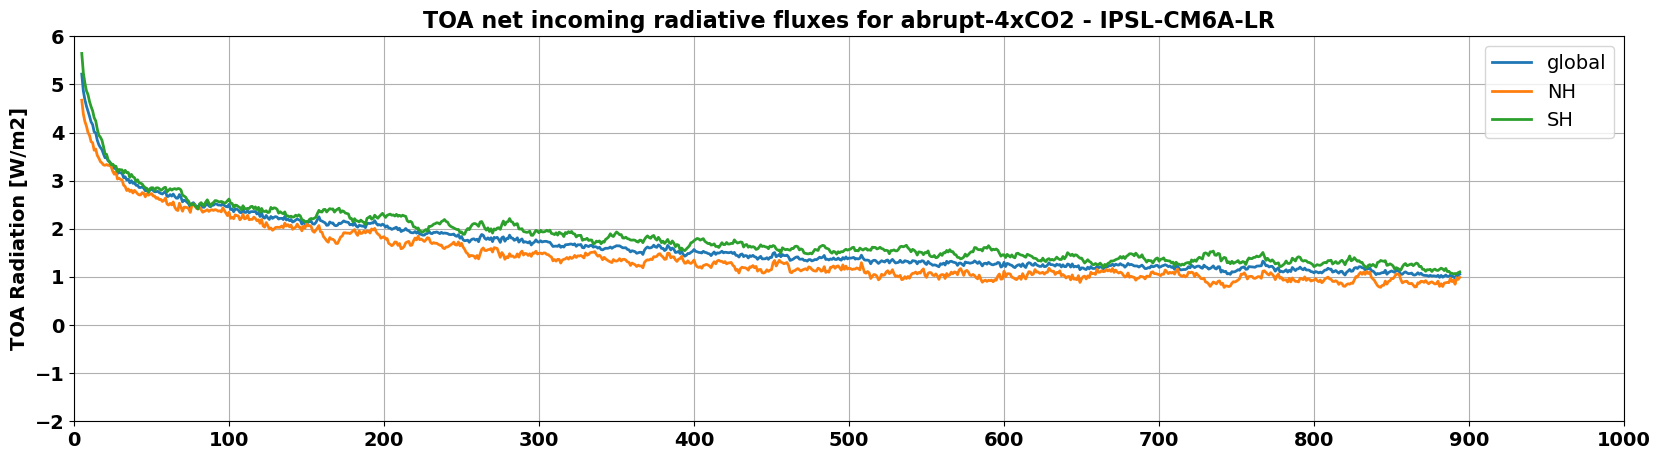

In [24]:
#%%commment
time = np.arange(0, 900)
time_roll = np.arange(5, 895)

plt.figure(figsize=(20, 5))

plt.plot(time_roll, roll_glb_imb_ipsl, color = 'tab:blue', linewidth = 2, label = 'global')

plt.plot(time_roll, roll_nh_imb_ipsl, color = 'tab:orange', linewidth = 2, label = 'NH')

plt.plot(time_roll, roll_sh_imb_ipsl, color = 'tab:green', linewidth = 2, label = 'SH')

plt.xlim(0, 1000)
plt.ylim(-2, 6)
#plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('TOA Radiation [W/m2]', fontsize=14, fontweight='bold')
plt.title('TOA net incoming radiative fluxes for abrupt-4xCO2 - IPSL-CM6A-LR', fontsize=16, fontweight='bold')

plt.xticks(np.arange(0, 1001, 100), fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend(fontsize=14)
plt.grid()

## **Part 2: The atmospheric Heat Transport**

### **2.1. NorESM2-LM**

#### **1. Calculating the AHT**

functions taken from the Long_CMIP6_functions pytohn script

In [14]:
toa_zonal_ave_piControl_noresm2 = rsdt_zon_noresm2_piControl-rlut_zon_noresm2_piControl-rsut_zon_noresm2_piControl
atm_zonal_ave_piControl_noresm2 = toa_zonal_ave_piControl_noresm2 + hfls_zon_noresm2_piControl + hfss_zon_noresm2_piControl + rlus_zon_noresm2_piControl+rsus_zon_noresm2_piControl-\
                          (rlds_zon_noresm2_piControl+ rsds_zon_noresm2_piControl)

toa_ht_piControl_noresm2 = heat_transport_vect('NorESM2-LM', toa_zonal_ave_piControl_noresm2, lat_noresm2)
atm_ht_piControl_noresm2 = heat_transport_vect('NorESM2-LM', atm_zonal_ave_piControl_noresm2, lat_noresm2)

In [15]:
toa_zonal_ave_x4CO2_noresm2 = rsdt_zon_noresm2_x4CO2-rlut_zon_noresm2_x4CO2-rsut_zon_noresm2_x4CO2
atm_zonal_ave_x4CO2_noresm2 = toa_zonal_ave_x4CO2_noresm2 + hfls_zon_noresm2_x4CO2 + hfss_zon_noresm2_x4CO2 + rlus_zon_noresm2_x4CO2+rsus_zon_noresm2_x4CO2-\
                          (rlds_zon_noresm2_x4CO2+ rsds_zon_noresm2_x4CO2)

toa_ht_x4CO2_noresm2 = heat_transport_vect('NorESM2-LM', toa_zonal_ave_x4CO2_noresm2, lat_noresm2)
atm_ht_x4CO2_noresm2 = heat_transport_vect('NorESM2-LM', atm_zonal_ave_x4CO2_noresm2, lat_noresm2)

In [20]:
save_dir = '/home/chrikap/Desktop/atmospheric_heat_transport/heat_transport_datasets/Annual_Variations/CMIP6/Paper_Scripts/GitHub_final_scripts/local_data/long_scale_noresm2_lm')

f_toa_ht_piControl_noresm2 = f"{save_dir}/toa_ht_piControl_noresm2.npy"
f_atm_ht_piControl_noresm2 = f"{save_dir}/atm_ht_piControl_noresm2.npy"
f_toa_ht_x4CO2_noresm2 = f"{save_dir}/toa_ht_x4CO2_noresm2.npy"
f_atm_ht_x4CO2_noresm2 = f"{save_dir}/atm_ht_x4CO2_noresm2.npy"

np.save(ftoa_ht_piControl_noresm2, toa_ht_piControl_noresm2)
np.save(fatm_ht_piControl_noresm2, atm_ht_piControl_noresm2)
np.save(ftoa_ht_x4CO2_noresm2, toa_ht_x4CO2_noresm2)
np.save(fatm_ht_x4CO2_noresm2, atm_ht_x4CO2_noresm2)

#### **2. Plotting the latitudinal piControl values and anomalies**

In [3]:
load_dir = '/home/chrikap/Desktop/atmospheric_heat_transport/heat_transport_datasets/Annual_Variations/CMIP6/Paper_Scripts/GitHub_final_scripts/local_data/long_scale_noresm2_lm')

toa_ht_piControl_noresm2 = np.load(f'{load_dir}/toa_ht_piControl_noresm2.npy')
atm_ht_piControl_noresm2 = np.load(f'{load_dir}/atm_ht_piControl_noresm2.npy')
toa_ht_x4CO2_noresm2 = np.load(f'{load_dir}/toa_ht_x4CO2_noresm2.npy')
atm_ht_x4CO2_noresm2 = np.load(f'{load_dir}/atm_ht_x4CO2_noresm2.npy')

lat_noresm2 = np.load(f'{load_dir}/lat_noresm2.npy')

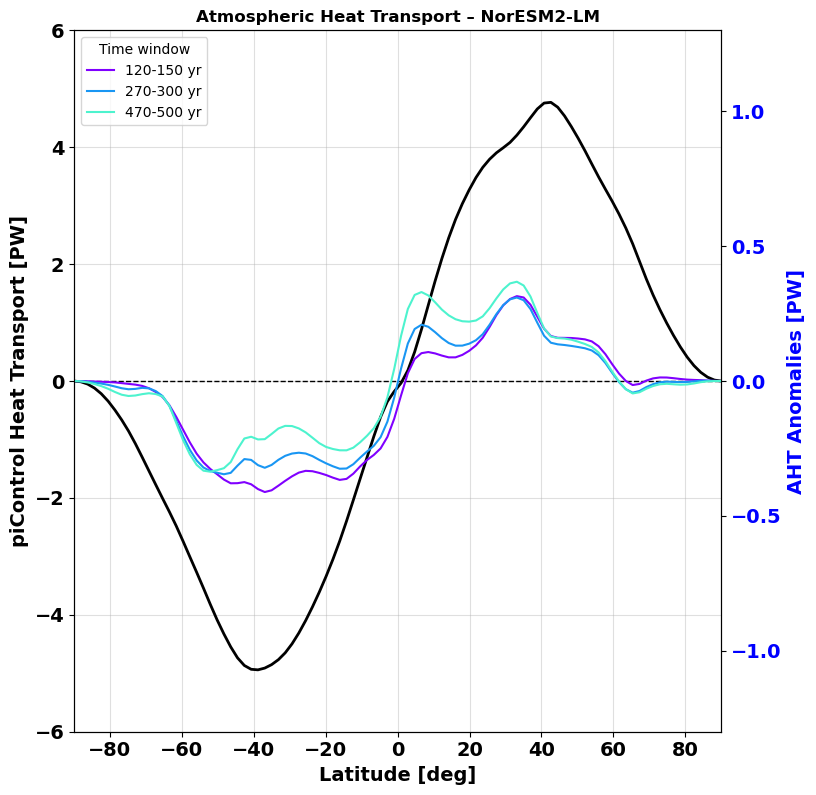

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 8))

# --- Left axis (for control / baseline) ---
ax1.plot(lat_noresm2, np.mean(atm_ht_piControl_noresm2[:, 0:30], axis=-1),
         color='black', label='piControl', linewidth=2)

ax1.set_xlabel('Latitude [deg]', fontsize=14, fontweight='bold')
ax1.set_ylabel('piControl Heat Transport [PW]', color='black', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')

# --- Add zero line for ax1 ---
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

time_windows = [(120, 150), (270, 300), (470, 500), (570, 600),
                (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:3], colors):
    anom = (np.mean(atm_ht_x4CO2_noresm2[:, start:end], axis=-1)
            - np.mean(atm_ht_piControl_noresm2[:, 0:30], axis=-1))

    ax2.plot(lat_noresm2, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('AHT Anomalies [PW]', color='blue', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

# --- Add zero line for ax2 ---
#ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, title="Time window")
ax1.set_ylim(-6, 6)
ax2.set_ylim(-1.3, 1.3)

plt.title('Atmospheric Heat Transport – NorESM2-LM', fontweight='bold')
plt.tight_layout()

# Make x-axis tick numbers stronger
ax1.tick_params(axis='x', labelsize=14)

# Left y-axis (piControl)
ax1.tick_params(axis='y', labelsize=14)

# Right y-axis (anomalies)
ax2.tick_params(axis='y', labelsize=14)

for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight('bold')

for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

plt.show()

#### **3. Plotting the timeseries for 36 N/S**

In [7]:
diff_N = np.abs(lat_noresm2 - 36)
min_diff_N = np.min(diff_N)

idx_36N = np.where(diff_N == min_diff_N)[0][0]
lat_36N = lat_noresm2[idx_36N]#.values

diff_S = np.abs(lat_noresm2 + 36)
min_diff_S = np.min(diff_S)

idx_36S = np.where(diff_S == min_diff_S)[0][0]
lat_36S = lat_noresm2[idx_36S]#.values

anom_aht_nh_noresm = atm_ht_x4CO2_noresm2[idx_36N, :]-np.mean(atm_ht_piControl_noresm2[idx_36N, :], axis =0)
anom_aht_sh_noresm = atm_ht_x4CO2_noresm2[idx_36S, :]-np.mean(atm_ht_piControl_noresm2[idx_36S, :], axis =0)

roll_anom_aht_nh_noresm = rolling_average_ts(anom_aht_nh_noresm, 11)
roll_anom_aht_sh_noresm = rolling_average_ts(anom_aht_sh_noresm, 11)

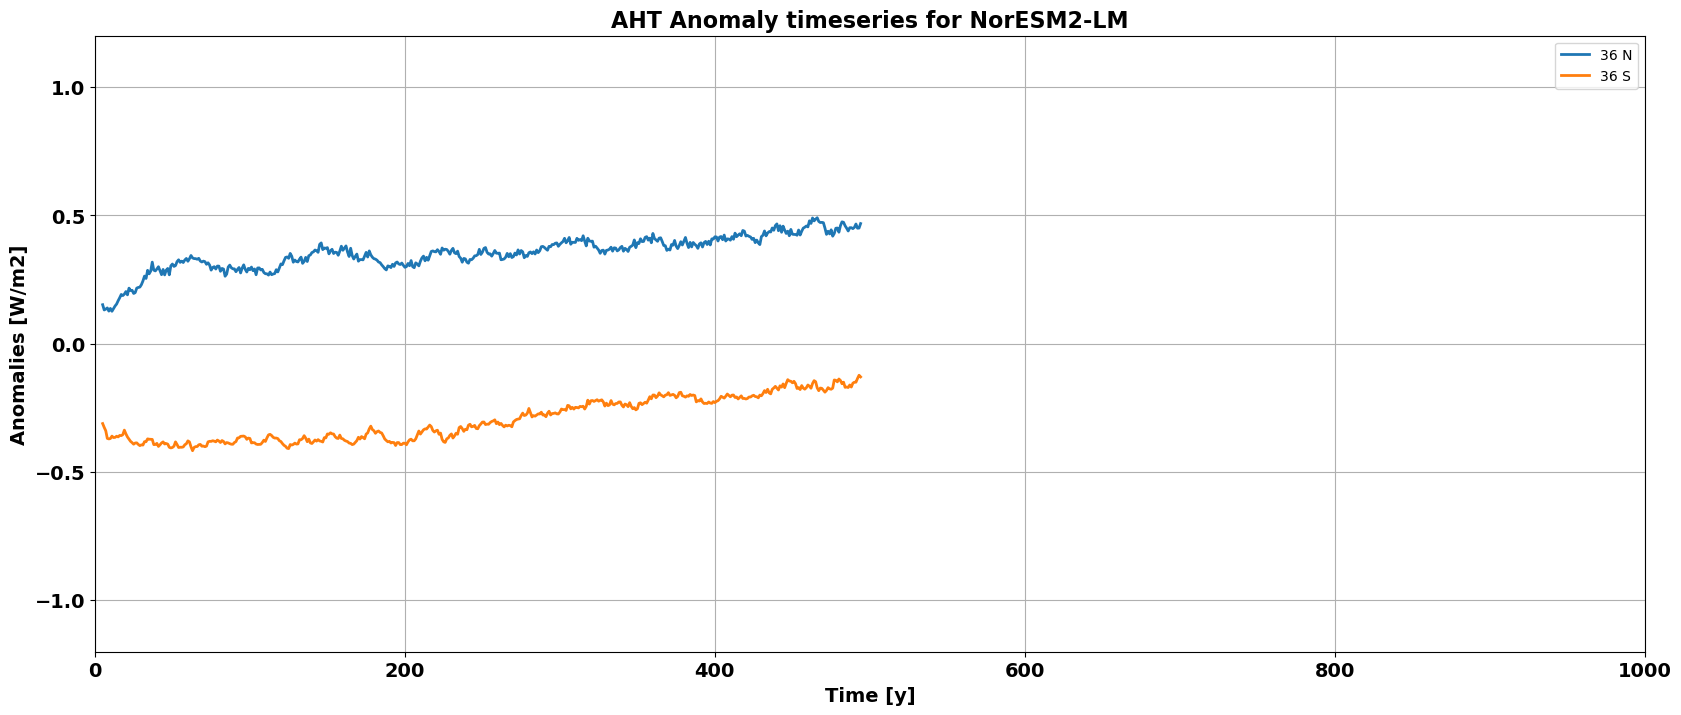

In [15]:
time = np.arange(5, 495)

plt.figure(figsize=(20, 8))

plt.plot(time, roll_anom_aht_nh_noresm, linewidth = 2, label = '36 N')

plt.plot(time, roll_anom_aht_sh_noresm, linewidth = 2, label = '36 S')

plt.xlim(0, 1000)
plt.ylim(-1.2, 1.2)
plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('Anomalies [W/m2]', fontsize=14, fontweight='bold')
plt.title(f'AHT Anomaly timeseries for NorESM2-LM', fontsize=16, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend()
plt.grid()

#### **4. Regridding to a common grid**

(the OHT is in a different grid. We will eventually have to add them together, so they need to be in a common grid)

In [3]:
target_lat = np.arange(-90, 92, 2)

In [4]:
toa_interp_piControl_noresm2 = regridding('NorESM2-LM', toa_ht_piControl_noresm2, lat_noresm2, target_lat)
atm_interp_piControl_noresm2 = regridding('NorESM2-LM', atm_ht_piControl_noresm2, lat_noresm2, target_lat)
toa_interp_x4CO2_noresm2 = regridding('NorESM2-LM', toa_ht_x4CO2_noresm2, lat_noresm2, target_lat)
atm_interp_x4CO2_noresm2 = regridding('NorESM2-LM', atm_ht_x4CO2_noresm2, lat_noresm2, target_lat)

In [5]:
atm_exp_noresm2 = np.stack([atm_interp_piControl_noresm2, atm_interp_x4CO2_noresm2], axis=0)
toa_exp_noresm2 = np.stack([toa_interp_piControl_noresm2, toa_interp_x4CO2_noresm2], axis=0)

### **2.2. IPSL-CM6A-LR**

#### **1. Calculating the AHT**

In [21]:
toa_zonal_ave_piControl_ipsl = rsdt_zon_ipsl_piControl-rlut_zon_ipsl_piControl-rsut_zon_ipsl_piControl
atm_zonal_ave_piControl_ipsl = toa_zonal_ave_piControl_ipsl + hfls_zon_ipsl_piControl + hfss_zon_ipsl_piControl + rlus_zon_ipsl_piControl+rsus_zon_ipsl_piControl-\
                          (rlds_zon_ipsl_piControl+ rsds_zon_ipsl_piControl)

toa_ht_piControl_ipsl = heat_transport_vect('IPSL-CM6A-LR', toa_zonal_ave_piControl_ipsl, lat_ipsl)
atm_ht_piControl_ipsl = heat_transport_vect('IPSL-CM6A-LR', atm_zonal_ave_piControl_ipsl, lat_ipsl)

toa_zonal_ave_x4CO2_ipsl = rsdt_zon_ipsl_x4CO2-rlut_zon_ipsl_x4CO2-rsut_zon_ipsl_x4CO2
atm_zonal_ave_x4CO2_ipsl = toa_zonal_ave_x4CO2_ipsl + hfls_zon_ipsl_x4CO2 + hfss_zon_ipsl_x4CO2 + rlus_zon_ipsl_x4CO2+rsus_zon_ipsl_x4CO2-\
                          (rlds_zon_ipsl_x4CO2+ rsds_zon_ipsl_x4CO2)

toa_ht_x4CO2_ipsl = heat_transport_vect('IPSL-CM6A-LR', toa_zonal_ave_x4CO2_ipsl, lat_ipsl)
atm_ht_x4CO2_ipsl = heat_transport_vect('IPSL-CM6A-LR', atm_zonal_ave_x4CO2_ipsl, lat_ipsl)

In [ ]:
save_dir = '/home/chrikap/Desktop/atmospheric_heat_transport/heat_transport_datasets/Annual_Variations/CMIP6/Paper_Scripts/GitHub_final_scripts/local_data/long_scale_ipsl')

f_toa_ht_piControl_ipsl = f"{save_dir}/toa_ht_piControl_ipsl.npy"
f_atm_ht_piControl_ipsl = f"{save_dir}/atm_ht_piControl_ipsl.npy"
f_toa_ht_x4CO2_ipsl = f"{save_dir}/toa_ht_x4CO2_ipsl.npy"
f_atm_ht_x4CO2_ipsl = f"{save_dir}/atm_ht_x4CO2_ipsl.npy"

np.save(f_toa_ht_piControl_ipsl, toa_ht_piControl_ipsl)
np.save(f_atm_ht_piControl_ipsl, atm_ht_piControl_ipsl)
np.save(f_toa_ht_x4CO2_ipsl, toa_ht_x4CO2_ipsl)
np.save(f_atm_ht_x4CO2_ipsl, atm_ht_x4CO2_ipsl)

#### **2. Plotting the latitudinal piControl values and anomalies**

In [7]:
load_dir = '/home/chrikap/Desktop/atmospheric_heat_transport/heat_transport_datasets/Annual_Variations/CMIP6/Paper_Scripts/GitHub_final_scripts/local_data/long_scale_ipsl')

toa_ht_piControl_ipsl = np.load(f'{load_dir}/toa_ht_piControl_ipsl.npy')
atm_ht_piControl_ipsl = np.load(f'{load_dir}/atm_ht_piControl_ipsl.npy')
toa_ht_x4CO2_ipsl = np.load(f'{load_dir}/toa_ht_x4CO2_ipsl.npy')
atm_ht_x4CO2_ipsl = np.load(f'{load_dir}/atm_ht_x4CO2_ipsl.npy')

lat_ipsl = np.load(f'{load_dir}/lat_ipsl.npy')

### **NB! IPSL x4CO2 branches of at year 20, so we don't use the first 20 years of piControl to compare!**

**The first functioning 30 years are therefore y 21-51**

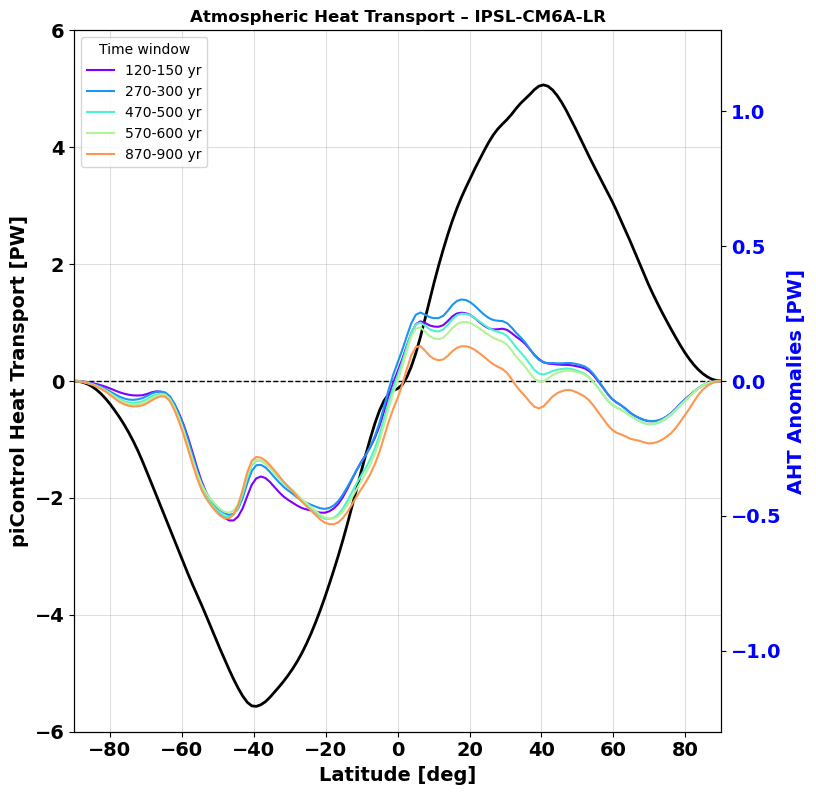

In [18]:
fig, ax1 = plt.subplots(figsize=(8, 8))

# --- Left axis (for control / baseline) ---

ax1.plot(lat_ipsl, np.mean(atm_ht_piControl_ipsl[:, 21:51], axis=-1),
         color='black', label='piControl', linewidth=2)

ax1.set_xlabel('Latitude [deg]', fontsize=14, fontweight='bold')
ax1.set_ylabel('piControl Heat Transport [PW]', color='black', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')

# --- Add zero line for ax1 ---
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

time_windows = [(120, 150), (270, 300), (470, 500), (570, 600),
                (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:-1], colors):
    anom = (np.mean(atm_ht_x4CO2_ipsl[:, start:end], axis=-1)
            - np.mean(atm_ht_piControl_ipsl[:, 21:51], axis=-1))

    ax2.plot(lat_ipsl, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('AHT Anomalies [PW]', color='blue', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

# --- Add zero line for ax2 ---
#ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, title="Time window")
ax1.set_ylim(-6, 6)
ax2.set_ylim(-1.3, 1.3)

plt.title('Atmospheric Heat Transport – IPSL-CM6A-LR', fontweight='bold')
plt.tight_layout()

# Make x-axis tick numbers stronger
ax1.tick_params(axis='x', labelsize=14)

# Left y-axis (piControl)
ax1.tick_params(axis='y', labelsize=14)

# Right y-axis (anomalies)
ax2.tick_params(axis='y', labelsize=14)

for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight('bold')

for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

plt.show()

In [10]:
np.where(np.mean(atm_ht_piControl_ipsl[:, 21:51], axis=-1) == np.min(np.mean(atm_ht_piControl_ipsl[:, 21:51], axis=-1)))

(array([40]),)

In [11]:
lat_ipsl[40]

-39.295776

#### **3. Plotting the timeseries for 36 N/S**

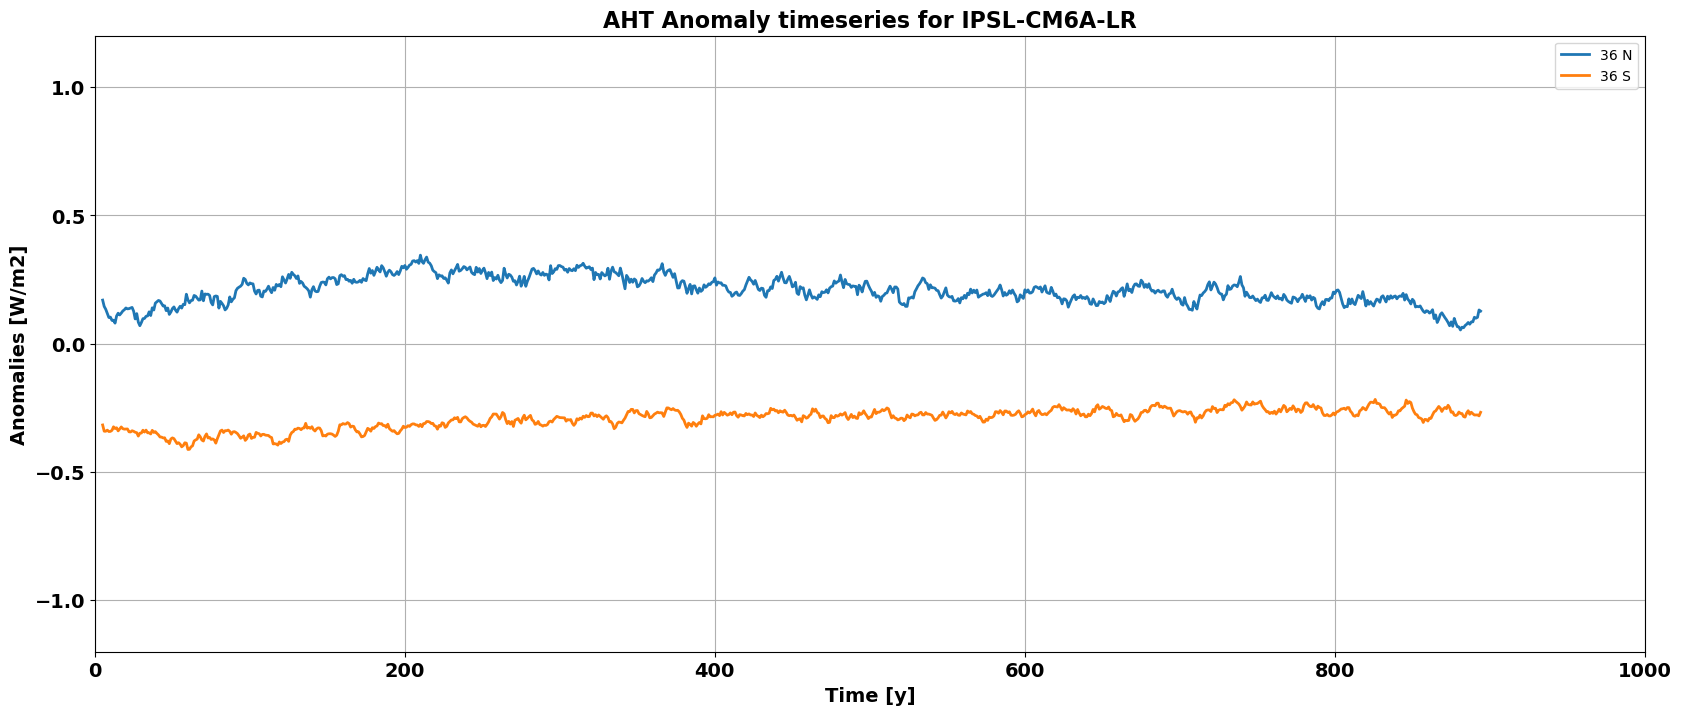

In [16]:
diff_N = np.abs(lat_ipsl - 36)
min_diff_N = np.min(diff_N)

idx_36N = np.where(diff_N == min_diff_N)[0][0]
lat_36N = lat_ipsl[idx_36N]#.values

diff_S = np.abs(lat_ipsl + 36)
min_diff_S = np.min(diff_S)

idx_36S = np.where(diff_S == min_diff_S)[0][0]
lat_36S = lat_ipsl[idx_36S]#.values

anom_aht_nh_ipsl = atm_ht_x4CO2_ipsl[idx_36N, :]-np.mean(atm_ht_piControl_ipsl[idx_36N, :], axis =0)
anom_aht_sh_ipsl = atm_ht_x4CO2_ipsl[idx_36S, :]-np.mean(atm_ht_piControl_ipsl[idx_36S, :], axis =0)

roll_anom_aht_nh_ipsl = rolling_average_ts(anom_aht_nh_ipsl, 11)
roll_anom_aht_sh_ipsl = rolling_average_ts(anom_aht_sh_ipsl, 11)

time = np.arange(5, 895)

plt.figure(figsize=(20, 8))

plt.plot(time, roll_anom_aht_nh_ipsl, linewidth = 2, label = '36 N')

plt.plot(time, roll_anom_aht_sh_ipsl, linewidth = 2, label = '36 S')

plt.xlim(0, 1000)
plt.ylim(-1.2, 1.2)
plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('Anomalies [W/m2]', fontsize=14, fontweight='bold')
plt.title(f'AHT Anomaly timeseries for IPSL-CM6A-LR', fontsize=16, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend()
plt.grid()

#### **4. Regridding to a common grid**

In [7]:
toa_interp_piControl_ipsl = regridding('IPSL-CM6A-LR', toa_ht_piControl_ipsl, lat_ipsl, target_lat)
atm_interp_piControl_ipsl = regridding('IPSL-CM6A-LR', atm_ht_piControl_ipsl, lat_ipsl, target_lat)
toa_interp_x4CO2_ipsl = regridding('IPSL-CM6A-LR', toa_ht_x4CO2_ipsl, lat_ipsl, target_lat)
atm_interp_x4CO2_ipsl = regridding('IPSL-CM6A-LR', atm_ht_x4CO2_ipsl, lat_ipsl, target_lat)

In [8]:
atm_exp_ipsl = np.stack([atm_interp_piControl_ipsl, atm_interp_x4CO2_ipsl], axis=0)
toa_exp_ipsl = np.stack([toa_interp_piControl_ipsl, toa_interp_x4CO2_ipsl], axis=0)

## **Part 3: The Ocean Heat Transport**

### **3.1. NorESM2-LM**

#### **1. Get hfbasin**

hfbasin is the CMIP6 output value for the OHT. It is usually split into Atlantic, Indo-Pacific and Global ocean basins.

In [30]:
hfbasins_gl_exp_noresm2, hfbasins_atl_exp_noresm2, hfbasins_ip_exp_noresm2, oc_lat_noresm2 = ocean_ht('NorESM2-LM', experiments, 0, 500*12)

Original: 'atlantic_arctic_ocean', Cleaned: 'atlantic_arctic_ocean', Mapped: 'atlantic_arctic_ocean'
Original: 'atlantic_arctic_extended_ocean', Cleaned: 'atlantic_arctic_extended_ocean', Mapped: 'unknown_atlantic_arctic_extended_ocean'
Original: 'indian_pacific_ocean', Cleaned: 'indian_pacific_ocean', Mapped: 'indian_pacific_ocean'
Original: 'global_ocean', Cleaned: 'global_ocean', Mapped: 'global_ocean'
Basin Mapping: {0: 'atlantic_arctic_ocean', 1: 'unknown_atlantic_arctic_extended_ocean', 2: 'indian_pacific_ocean', 3: 'global_ocean'}
Original: 'atlantic_arctic_ocean', Cleaned: 'atlantic_arctic_ocean', Mapped: 'atlantic_arctic_ocean'
Original: 'atlantic_arctic_extended_ocean', Cleaned: 'atlantic_arctic_extended_ocean', Mapped: 'unknown_atlantic_arctic_extended_ocean'
Original: 'indian_pacific_ocean', Cleaned: 'indian_pacific_ocean', Mapped: 'indian_pacific_ocean'
Original: 'global_ocean', Cleaned: 'global_ocean', Mapped: 'global_ocean'
Basin Mapping: {0: 'atlantic_arctic_ocean', 1: 

In [4]:
save_dir = save_dir = '/home/chrikap/Desktop/atmospheric_heat_transport/heat_transport_datasets/Annual_Variations/CMIP6/Paper_Scripts/GitHub_final_scripts/local_data/long_scale_noresm2_lm')

f_hfbasins_gl_exp_noresm2 = f"{save_dir}/hfbasins_gl_exp_noresm2.npy"
f_hfbasins_atl_exp_noresm2 = f"{save_dir}/hfbasins_atl_exp_noresm2.npy"
f_hfbasins_ip_exp_noresm2 = f"{save_dir}/hfbasins_ip_exp_noresm2.npy"
f_oc_lat_noresm2 = f"{save_dir}/oc_lat_noresm2.npy"

np.save(f_hfbasins_gl_exp_noresm2, hfbasins_gl_exp_noresm2)
np.save(f_hfbasins_atl_exp_noresm2, hfbasins_atl_exp_noresm2)
np.save(f_hfbasins_ip_exp_noresm2, hfbasins_ip_exp_noresm2)
np.save(f_oc_lat_noresm2, oc_lat_noresm2)

#### **2. Plotting the timeseries for 36 N/S**

In [12]:
load_dir = '/home/chrikap/Desktop/atmospheric_heat_transport/heat_transport_datasets/Annual_Variations/CMIP6/Paper_Scripts/GitHub_final_scripts/local_data/long_scale_noresm2_lm')

hfbasins_gl_exp_noresm2 = np.load(f'{load_dir}/hfbasins_gl_exp_noresm2.npy')
hfbasins_atl_exp_noresm2 = np.load(f'{load_dir}/hfbasins_atl_exp_noresm2.npy')
hfbasins_ip_exp_noresm2 = np.load(f'{load_dir}/hfbasins_ip_exp_noresm2.npy')
oc_lat_noresm2 = np.load(f'{load_dir}/oc_lat_noresm2.npy')

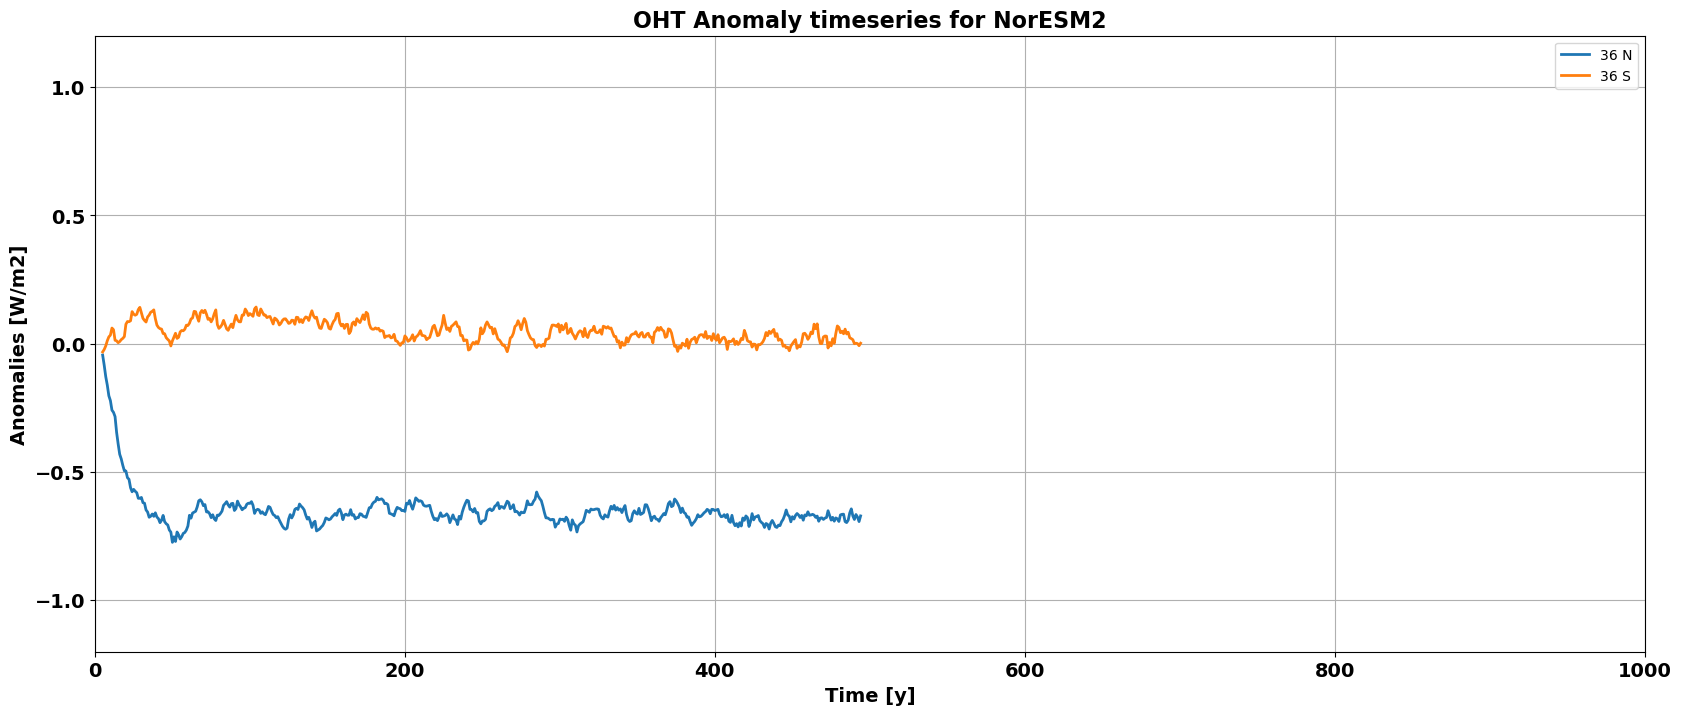

In [10]:
diff_N = np.abs(oc_lat_noresm2 - 36)
min_diff_N = np.min(diff_N)

idx_36N = np.where(diff_N == min_diff_N)[0][0]
lat_36N = oc_lat_noresm2[idx_36N]#.values

diff_S = np.abs(oc_lat_noresm2 + 36)
min_diff_S = np.min(diff_S)

idx_36S = np.where(diff_S == min_diff_S)[0][0]
lat_36S = oc_lat_noresm2[idx_36S]#.values

anom_oht_nh_noresm2 = hfbasins_gl_exp_noresm2[1, :, idx_36N]-np.mean(hfbasins_gl_exp_noresm2[0, :, idx_36N], axis =0)
anom_oht_sh_noresm2 = hfbasins_gl_exp_noresm2[1, :, idx_36S]-np.mean(hfbasins_gl_exp_noresm2[0, :, idx_36S], axis =0)

roll_anom_oht_nh_noresm2 = rolling_average_ts(anom_oht_nh_noresm2, 11)
roll_anom_oht_sh_noresm2 = rolling_average_ts(anom_oht_sh_noresm2, 11)

time = np.arange(5, 495)

plt.figure(figsize=(20, 8))

plt.plot(time, roll_anom_oht_nh_noresm2, linewidth = 2, label = '36 N')

plt.plot(time, roll_anom_oht_sh_noresm2, linewidth = 2, label = '36 S')

plt.xlim(0, 1000)
plt.ylim(-1.2, 1.2)
plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('Anomalies [W/m2]', fontsize=14, fontweight='bold')
plt.title(f'OHT Anomaly timeseries for NorESM2', fontsize=16, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend()
plt.grid()

#### **3. Plotting the Global OHT and splitting into Atlantic and Indo-Pacific Oceans for diagnosing**

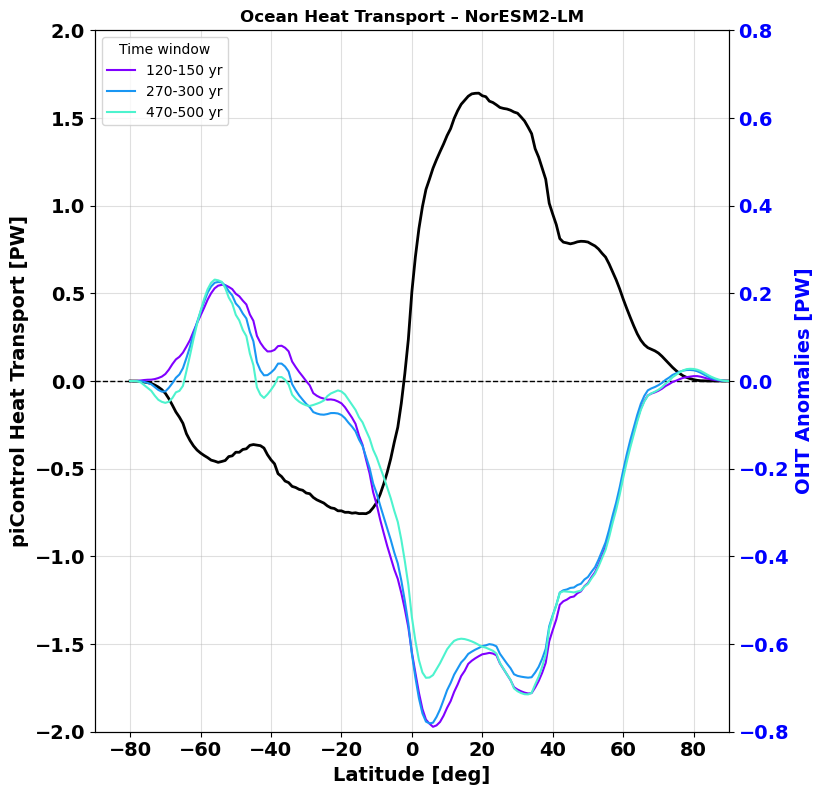

In [26]:
fig, ax1 = plt.subplots(figsize=(8, 8))

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_noresm2, np.mean(hfbasins_gl_exp_noresm2[0, 0:30, :], axis = 0),
         color='black', label='piControl', linewidth=2)

ax1.set_xlabel('Latitude [deg]', fontsize=14, fontweight='bold')
ax1.set_ylabel('piControl Heat Transport [PW]', color='black', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')

# --- Add zero line for ax1 ---
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

time_windows = [(120, 150), (270, 300), (470, 500), (570, 600),
                (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:3], colors):
    anom = (np.mean(hfbasins_gl_exp_noresm2[1, start:end, :], axis=0)\
          - np.mean(hfbasins_gl_exp_noresm2[0, 0:30, :], axis=0))
    ax2.plot(oc_lat_noresm2, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('OHT Anomalies [PW]', color='blue', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

# --- Add zero line for ax2 ---
#ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, title="Time window")

plt.title('Ocean Heat Transport – NorESM2-LM', fontweight='bold')
plt.tight_layout()

# Make x-axis tick numbers stronger
ax1.tick_params(axis='x', labelsize=14)

# Left y-axis (piControl)
ax1.tick_params(axis='y', labelsize=14)

# Right y-axis (anomalies)
ax2.tick_params(axis='y', labelsize=14)

for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight('bold')

for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

plt.show()

In [73]:
np.where(np.mean(hfbasins_gl_exp_noresm2[0, 0:30, :], axis = 0) == np.min(np.mean(hfbasins_gl_exp_noresm2[0, 0:30, 31:79], axis = 0)))

(array([67]),)

In [80]:
np.where((np.mean(hfbasins_gl_exp_noresm2[1, 270:300, :], axis=0)\
          - np.mean(hfbasins_gl_exp_noresm2[0, 0:30, :], axis=0)) == np.min((np.mean(hfbasins_gl_exp_noresm2[1, 270:300, 101:119], axis=0)\
          - np.mean(hfbasins_gl_exp_noresm2[0, 0:30, 101:119], axis=0))))

(array([113]),)

In [79]:
np.where((oc_lat_noresm2<40)&(oc_lat_noresm2>20))

(array([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
        114, 115, 116, 117, 118, 119]),)

In [81]:
oc_lat_noresm2[113]

33.0

In [75]:
np.mean(hfbasins_gl_exp_noresm2[0, 0:30, :], axis = 0)[67]

-0.7565097265282312

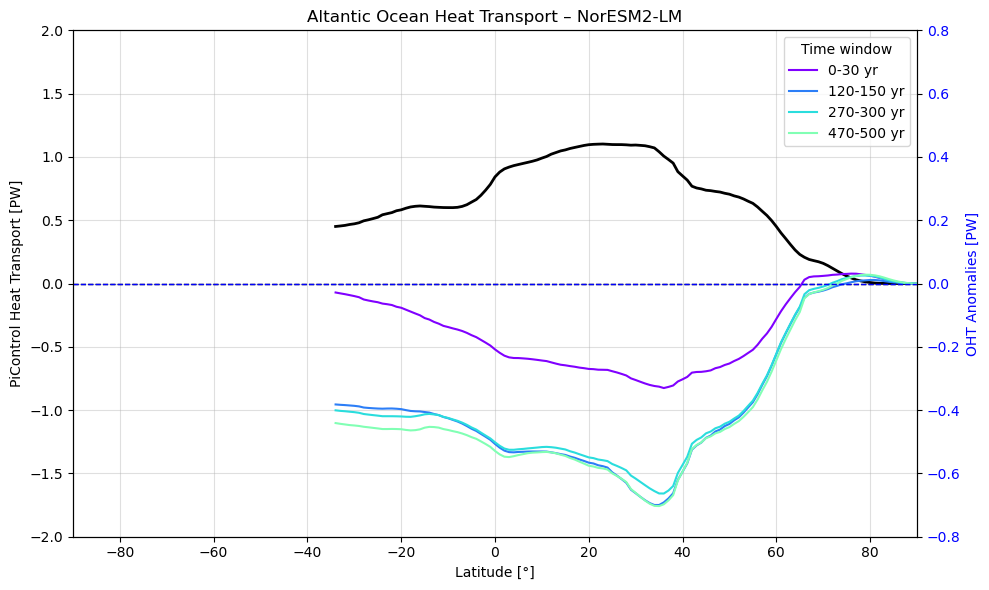

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_noresm2[46:], np.mean(hfbasins_atl_exp_noresm2[0, 0:30, 46:], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:4], colors):
    anom = (np.mean(hfbasins_atl_exp_noresm2[1, start:end, :], axis=0)\
          - np.mean(hfbasins_atl_exp_noresm2[0, 0:30, :], axis=0))
    ax2.plot(oc_lat_noresm2[46:], anom[46:], color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)
ax1.set_xlim(-90, 90)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper right', fontsize=10, title="Time window")

plt.title('Altantic Ocean Heat Transport – NorESM2-LM')
plt.tight_layout()
plt.show()

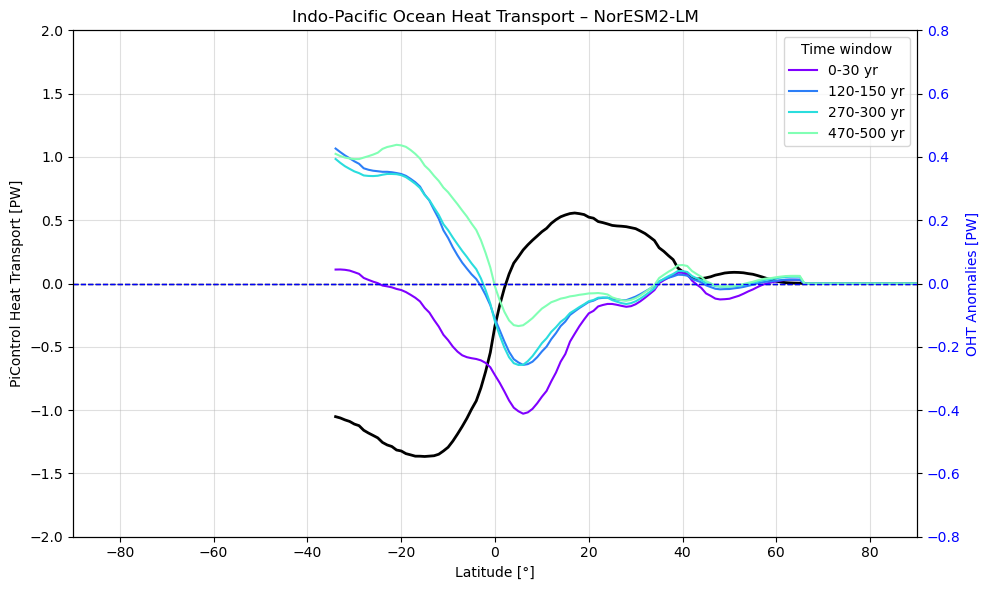

In [28]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_noresm2[46:], np.mean(hfbasins_ip_exp_noresm2[0, 0:30, 46:], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:4], colors):
    anom = (np.mean(hfbasins_ip_exp_noresm2[1, start:end, :], axis=0)\
          - np.mean(hfbasins_ip_exp_noresm2[0, 0:30, :], axis=0))
    ax2.plot(oc_lat_noresm2[46:], anom[46:], color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)
ax1.set_xlim(-90, 90)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper right', fontsize=10, title="Time window")

plt.title('Indo-Pacific Ocean Heat Transport – NorESM2-LM')
plt.tight_layout()
plt.show()

### **3.2. IPSL-CM6A-LR**

#### **1. Get hfbasin**

In [33]:
hfbasins_gl_exp_ipsl, hfbasins_atl_exp_ipsl, hfbasins_ip_exp_ipsl, oc_lat_ipsl = ocean_ht('IPSL-CM6A-LR', experiments, 0, 900*12)

Original: 'Global', Cleaned: 'Global', Mapped: 'global_ocean'
Original: 'Atlantic', Cleaned: 'Atlantic', Mapped: 'atlantic_arctic_ocean'
Original: 'indian_pacific_ocean', Cleaned: 'indian_pacific_ocean', Mapped: 'indian_pacific_ocean'
Basin Mapping: {0: 'global_ocean', 1: 'atlantic_arctic_ocean', 2: 'indian_pacific_ocean'}
Original: 'Global', Cleaned: 'Global', Mapped: 'global_ocean'
Original: 'Atlantic', Cleaned: 'Atlantic', Mapped: 'atlantic_arctic_ocean'
Original: 'indian_pacific_ocean', Cleaned: 'indian_pacific_ocean', Mapped: 'indian_pacific_ocean'
Basin Mapping: {0: 'global_ocean', 1: 'atlantic_arctic_ocean', 2: 'indian_pacific_ocean'}


In [12]:
save_dir = '/home/chrikap/Desktop/atmospheric_heat_transport/heat_transport_datasets/Annual_Variations/CMIP6/Paper_Scripts/GitHub_final_scripts/local_data/long_scale_ipsl')

f_hfbasins_gl_exp_ipsl = f"{save_dir}/hfbasins_gl_exp_ipsl.npy"
f_hfbasins_atl_exp_ipsl = f"{save_dir}/hfbasins_atl_exp_ipsl.npy"
f_hfbasins_ip_exp_ipsl = f"{save_dir}/hfbasins_ip_exp_ipsl.npy"
f_oc_lat_ipsl = f"{save_dir}/oc_lat_ipsl.npy"

np.save(f_hfbasins_gl_exp_ipsl, hfbasins_gl_exp_ipsl)
np.save(f_hfbasins_atl_exp_ipsl, hfbasins_atl_exp_ipsl)
np.save(f_hfbasins_ip_exp_ipsl, hfbasins_ip_exp_ipsl)
np.save(f_oc_lat_ipsl, oc_lat_ipsl)

#### **2. Plotting the timeseries for 36 N/S**

In [18]:
os.chdir('/home/chrikap/Desktop/atmospheric heat transport/heat transport datasets/Annual_Variations/CMIP6/Paper_Scripts/long_scale_ipsl')

hfbasins_gl_exp_ipsl = np.load(f'{load_dir}/hfbasins_gl_exp_ipsl.npy')
hfbasins_atl_exp_ipsl = np.load(f'{load_dir}/hfbasins_atl_exp_ipsl.npy')
hfbasins_ip_exp_ipsl = np.load(f'{load_dir}/hfbasins_ip_exp_ipsl.npy')
oc_lat_ipsl = np.load(f'{load_dir}/oc_lat_ipsl.npy')

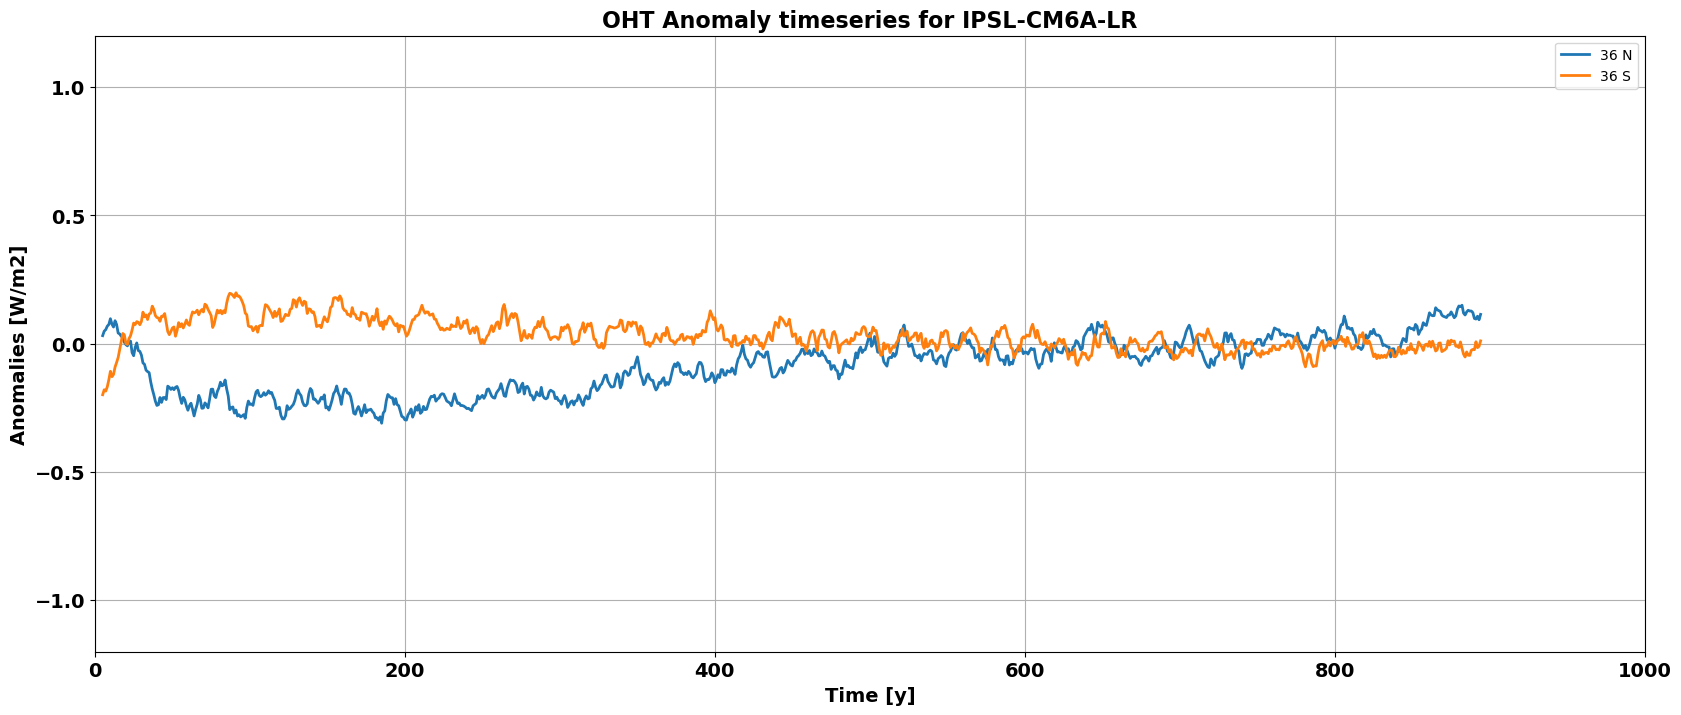

In [13]:
diff_N = np.abs(oc_lat_ipsl - 36)
min_diff_N = np.min(diff_N)

idx_36N = np.where(diff_N == min_diff_N)[0][0]
lat_36N = oc_lat_ipsl[idx_36N]#.values

diff_S = np.abs(oc_lat_ipsl + 36)
min_diff_S = np.min(diff_S)

idx_36S = np.where(diff_S == min_diff_S)[0][0]
lat_36S = oc_lat_ipsl[idx_36S]#.values

anom_oht_nh_ipsl = hfbasins_gl_exp_ipsl[1, :, idx_36N]-np.mean(hfbasins_gl_exp_ipsl[0, :, idx_36N], axis =0)
anom_oht_sh_ipsl = hfbasins_gl_exp_ipsl[1, :, idx_36S]-np.mean(hfbasins_gl_exp_ipsl[0, :, idx_36S], axis =0)

roll_anom_oht_nh_ipsl = rolling_average_ts(anom_oht_nh_ipsl, 11)
roll_anom_oht_sh_ipsl = rolling_average_ts(anom_oht_sh_ipsl, 11)

time = np.arange(5, 895)

plt.figure(figsize=(20, 8))

plt.plot(time, roll_anom_oht_nh_ipsl, linewidth = 2, label = '36 N')

plt.plot(time, roll_anom_oht_sh_ipsl, linewidth = 2, label = '36 S')

plt.xlim(0, 1000)
plt.ylim(-1.2, 1.2)
plt.xlabel('Time [y]', fontsize=14, fontweight='bold')
plt.ylabel('Anomalies [W/m2]', fontsize=14, fontweight='bold')
plt.title(f'OHT Anomaly timeseries for IPSL-CM6A-LR', fontsize=16, fontweight='bold')
plt.xticks(fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.legend()
plt.grid()

#### **3. Plotting the Global OHT and splitting into Atlantic and Indo-Pacific Oceans for diagnosing**

### **like before, we work with years 21-52**

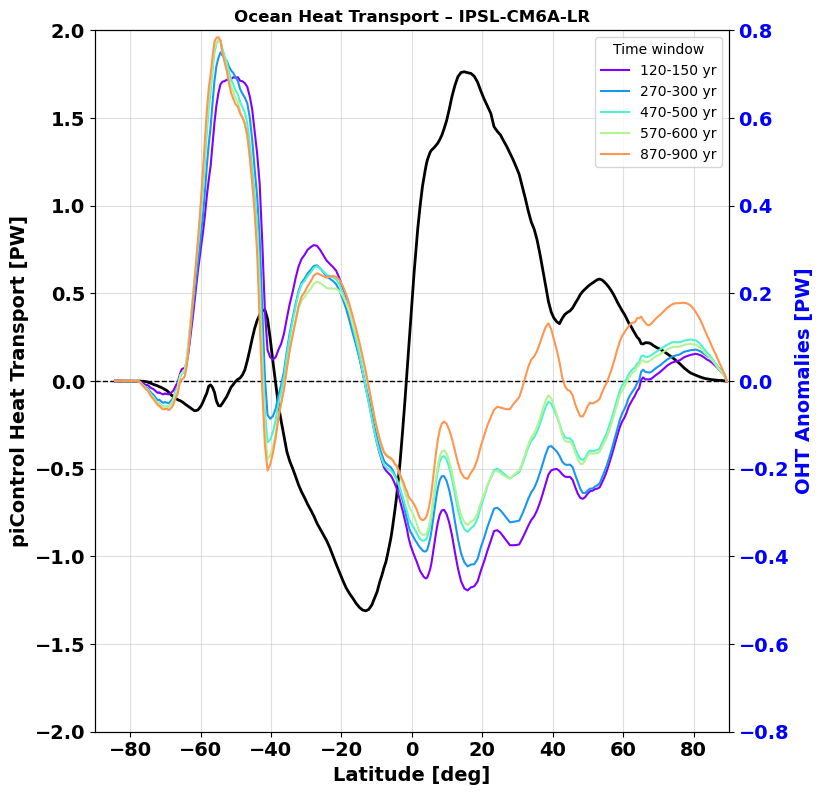

In [30]:
fig, ax1 = plt.subplots(figsize=(8, 8))

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_ipsl, np.mean(hfbasins_gl_exp_ipsl[0, 21:51, :, 0], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [deg]', fontsize=14, fontweight='bold')
ax1.set_ylabel('piControl Heat Transport [PW]', color='black', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')

# --- Add zero line for ax1 ---
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

time_windows = [(120, 150), (270, 300), (470, 500), (570, 600),
                (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:-1], colors):
    anom = (np.mean(hfbasins_gl_exp_ipsl[1, start:end, :, 0], axis=0)\
          - np.mean(hfbasins_gl_exp_ipsl[0, 21:51, :, 0], axis=0))
    ax2.plot(oc_lat_ipsl, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('OHT Anomalies [PW]', color='blue', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

# --- Add zero line for ax2 ---
#ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper right', fontsize=10, title="Time window")

plt.title('Ocean Heat Transport – IPSL-CM6A-LR', fontweight='bold')
plt.tight_layout()

# Make x-axis tick numbers stronger
ax1.tick_params(axis='x', labelsize=14)

# Left y-axis (piControl)
ax1.tick_params(axis='y', labelsize=14)

# Right y-axis (anomalies)
ax2.tick_params(axis='y', labelsize=14)

for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight('bold')

for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

plt.show()

In [67]:
np.where(np.mean(hfbasins_gl_exp_ipsl[0, 21:51, :, 0], axis = 0) == np.min(np.mean(hfbasins_gl_exp_ipsl[0, 21:51, 114:185, 0], axis = 0)))

(array([158]),)

In [66]:
np.where((oc_lat_ipsl <0) & (oc_lat_ipsl>-50))

(array([114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
        127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139,
        140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152,
        153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165,
        166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178,
        179, 180, 181, 182, 183, 184, 185]),)

In [68]:
oc_lat_ipsl[158]

-13.079

In [69]:
np.mean(hfbasins_gl_exp_ipsl[0, 21:51, :, 0], axis = 0)[158]

-1.3107112190519103

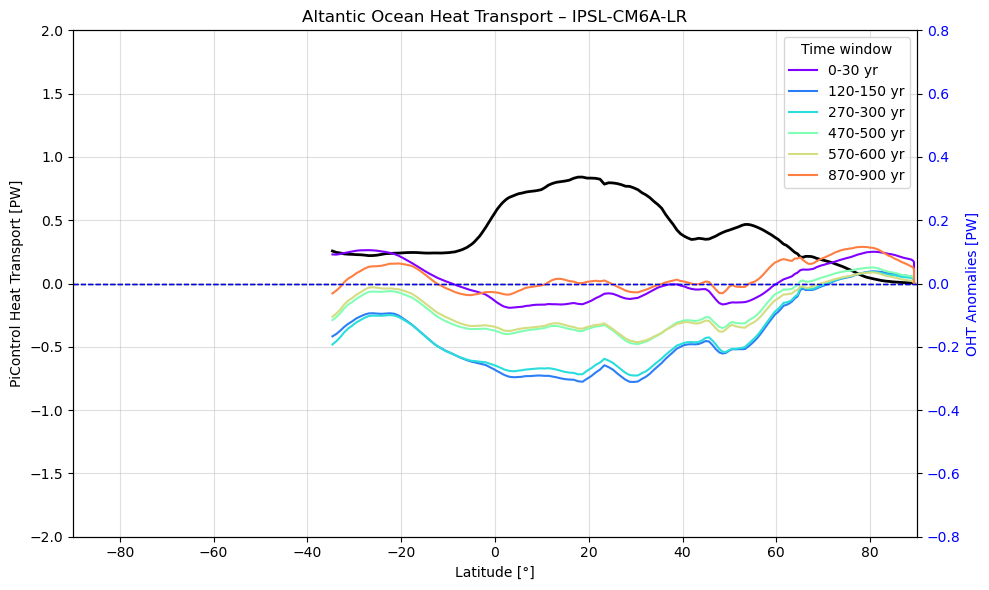

In [31]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_ipsl[134:], np.mean(hfbasins_atl_exp_ipsl[0, 21:51, 134:], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:6], colors):
    anom = (np.mean(hfbasins_atl_exp_ipsl[1, start:end, :], axis=0)\
          - np.mean(hfbasins_atl_exp_ipsl[0, 21:51, :], axis=0))
    ax2.plot(oc_lat_ipsl[134:], anom[134:], color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)
ax1.set_xlim(-90, 90)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper right', fontsize=10, title="Time window")

plt.title('Altantic Ocean Heat Transport – IPSL-CM6A-LR')
plt.tight_layout()
plt.show()

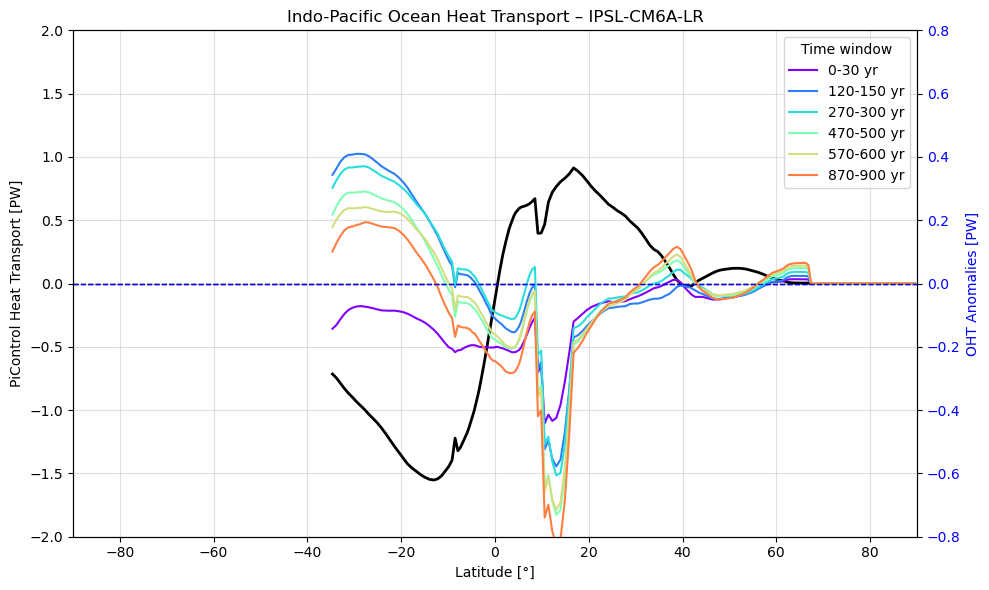

In [32]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# --- Left axis (for control / baseline) ---
ax1.plot(oc_lat_ipsl[134:], np.mean(hfbasins_ip_exp_ipsl[0, 21:51, 134:], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:6], colors):
    anom = (np.mean(hfbasins_ip_exp_ipsl[1, start:end, :], axis=0)\
          - np.mean(hfbasins_ip_exp_ipsl[0, 21:51, :], axis=0))
    ax2.plot(oc_lat_ipsl[134:], anom[134:], color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.8, 0.8)
ax1.set_xlim(-90, 90)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper right', fontsize=10, title="Time window")

plt.title('Indo-Pacific Ocean Heat Transport – IPSL-CM6A-LR')
plt.tight_layout()
plt.show()

## **Part 4: ATM + OHT**

### **4.1. NorESM2-LM**

#### **1. Regridding the OHT to the target latitude**

We use the regridding function from Long_VMIP6_functions

In [11]:
# Regridding
oht_noresm2 = ocean_regr_vec(hfbasins_gl_exp_noresm2, oc_lat_noresm2, target_lat)

#### **2. Turning the nan values to zeros for the latitudes with no OHT**

In [22]:
# Checking which latitudes/years have nan values
for i in range (2):
    for j in range(500):
        print(target_lat[np.where(np.isnan(oht_noresm2[i, j, :]))])

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[

In [23]:
# Checking which latitudes/years have tiny values for Heat Transport
for i in range(2):
    for j in range(500):
        print(target_lat[np.where(oht_noresm2[i, j, :] < -10)])
        if np.any(oht_noresm2[i, j] < -10):
            print(i, j)

[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[]
[

In [34]:
# Turning the nan values to zero
#oht_noresm2 = np.nan_to_num(oht_noresm2, nan=0)

#### **3. Calculating the Atm + OHT**

In [12]:
toa_sum = atm_exp_noresm2 + oht_noresm2

In [36]:
toa_sum.shape

(2, 500, 91)

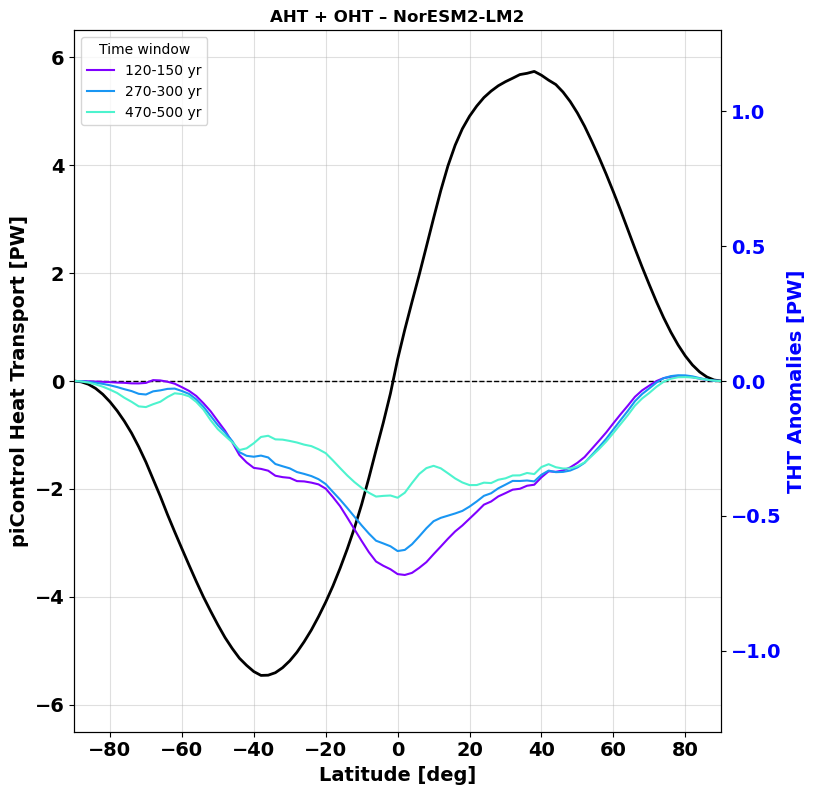

In [13]:
fig, ax1 = plt.subplots(figsize=(8, 8))

# --- Left axis (for control / baseline) ---
ax1.plot(target_lat, np.mean(toa_sum[0, 0:30, :], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [deg]', fontsize=14, fontweight='bold')
ax1.set_ylabel('piControl Heat Transport [PW]', color='black', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')

# --- Add zero line for ax1 ---
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

time_windows = [(120, 150), (270, 300), (470, 500), (570, 600),
                (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:3], colors):
    anom = (np.mean(toa_sum[1, start:end, :], axis=0)\
          - np.mean(toa_sum[0, 0:30, :], axis=0))
    
    ax2.plot(target_lat, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('THT Anomalies [PW]', color='blue', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

# --- Add zero line for ax2 ---
#ax2.axhline(0, color='blue', linestyle='--', linewidth=1)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.set_ylim(-6.5, 6.5)
ax2.set_ylim(-1.3, 1.3)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, title="Time window")

plt.title('AHT + OHT – NorESM2-LM2', fontweight='bold')
plt.tight_layout()

# Make x-axis tick numbers stronger
ax1.tick_params(axis='x', labelsize=14)

# Left y-axis (piControl)
ax1.tick_params(axis='y', labelsize=14)

# Right y-axis (anomalies)
ax2.tick_params(axis='y', labelsize=14)

for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight('bold')

for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

plt.show()

In [41]:
toa_ht_piControl_noresm2.shape

(96, 500)

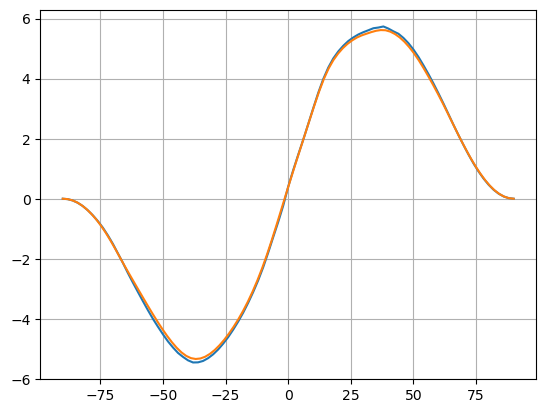

In [43]:
plt.plot(target_lat, np.mean(toa_sum[0, 0:30, :], axis = 0))
plt.plot(lat_noresm2, np.mean(toa_ht_piControl_noresm2[:, 0:30], axis = 1))
plt.grid()



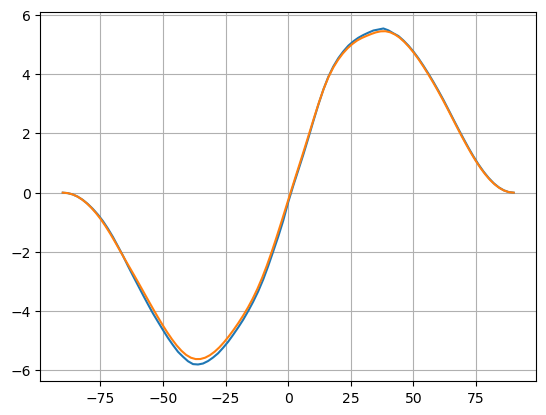

In [44]:
plt.plot(target_lat, np.mean(toa_sum[1, 0:30, :], axis = 0))
plt.plot(lat_noresm2, np.mean(toa_ht_x4CO2_noresm2[:, 0:30], axis = 1))
plt.grid()

In [32]:
lat_noresm2.shape

(96,)

In [36]:
lon_noresm2.shape

(144,)

In [37]:
atm_ht_piControl_noresm2.shape

(96, 500)

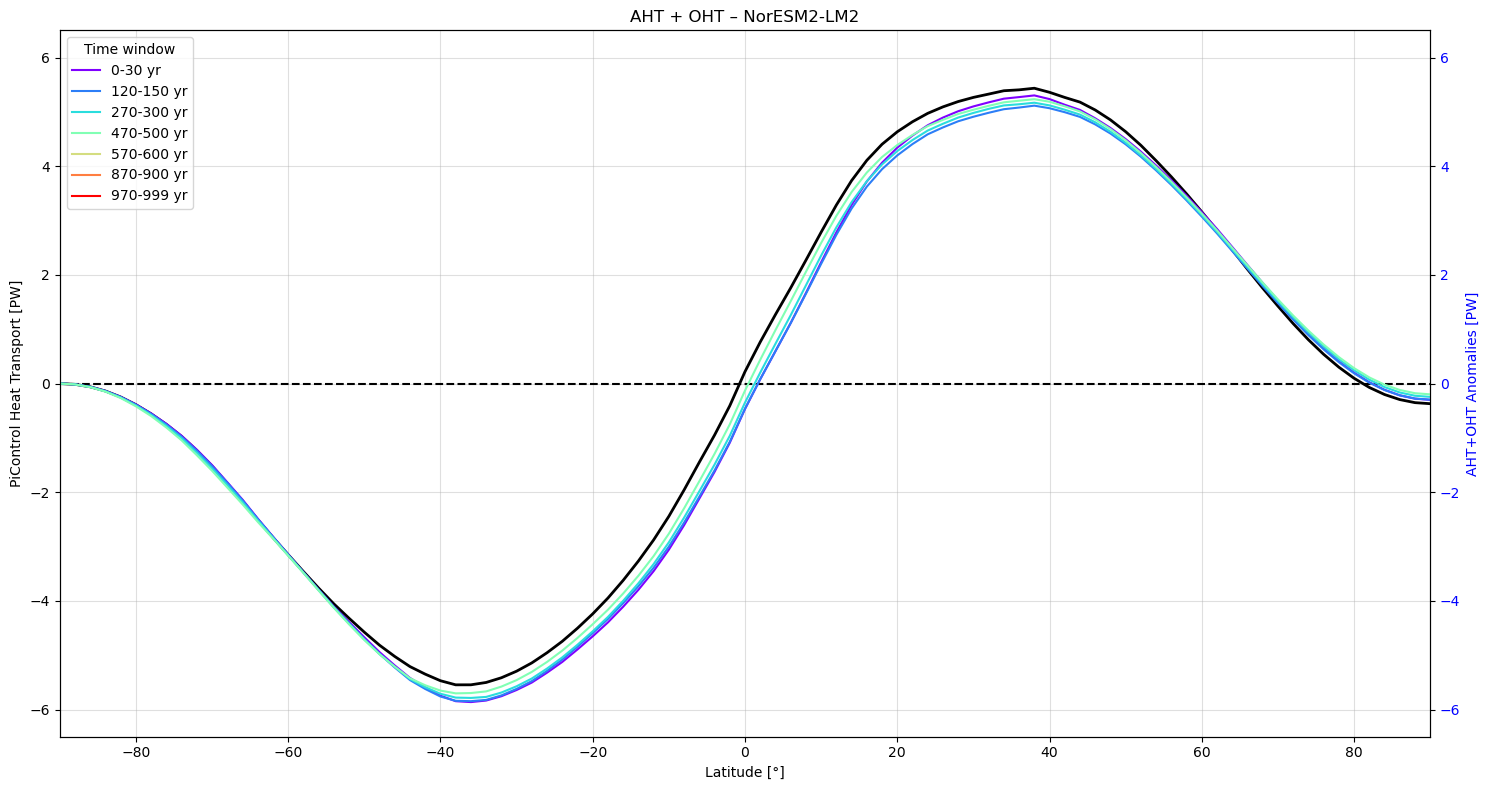

In [24]:
fig, ax1 = plt.subplots(figsize=(15, 8))

# --- Left axis (for control / baseline) ---
ax1.plot(target_lat, np.mean(toa_sum[0, :, :], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows, colors):
    x4 = (np.mean(toa_sum[1, start:end, :], axis=0))
    
    ax2.plot(target_lat, x4, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('AHT+OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax1.axhline(0, color='black', linestyle='--')
#ax2.axhline(0, color='blue', linestyle='--')
ax1.set_ylim(-6.5, 6.5)
ax2.set_ylim(-6.5, 6.5)
#ax2.set_ylim(-1.3, 1.3)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, title="Time window")

plt.title('AHT + OHT – NorESM2-LM2')
plt.tight_layout()
plt.show()

#### **4. Joe's idea for assessing BJC**

In [68]:
anom = np.array([(np.mean(toa_sum[1, i:i+30, :], axis=0) - np.mean(toa_sum[0, 0:30, :], axis=0)) for i in range(0, 500, 30)]) 

bounds_1 = [(-10, 10), (-10, 10), (-10, 10)]  # Assuming c is in [0, 10]
x_data = np.arange(anom.shape[0])

a_coeffs = []
b_coeffs = []
rms = []
y_fit_all = []

for i in range(anom.shape[1]):

    y_data = anom[:, i]
    
    result = differential_evolution(objective_function_1, bounds_1, args=(x_data, y_data), maxiter=1000)
    
    a1, b1, c = result.x
    
    y_fit = single_exponential(x_data, a1, b1, c)
    
    rms_error = np.sqrt(np.mean((y_data - y_fit) ** 2))

    a_coeffs.append(a1)
    b_coeffs.append(b1)
    rms.append(rms_error)
    y_fit_all.append(y_fit)

y_fit_all = np.array(y_fit_all)

Text(0, 0.5, 'b coeff')

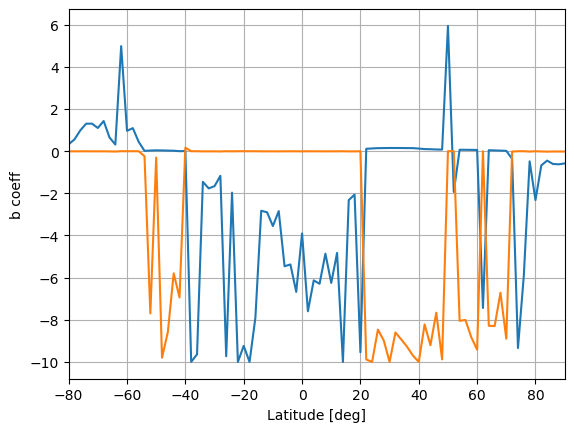

In [69]:
plt.plot(target_lat, a_coeffs)
plt.plot(target_lat, b_coeffs)
plt.grid()
plt.xlim(-80, 90)
#plt.ylim(-0.5,)
plt.xlabel('Latitude [deg]')
plt.ylabel('b coeff')

Text(0, 0.5, 'tendency of anomalies [PW/y]')

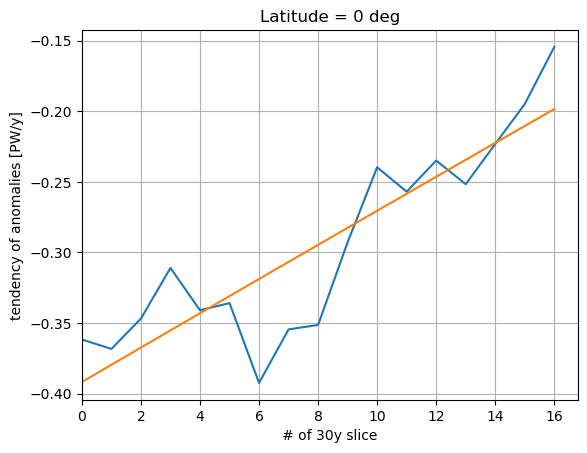

In [33]:
plt.plot(x_data, anom[:, 30])
plt.plot(x_data, y_fit_all[30, :])
plt.title('Latitude = 0 deg')
plt.grid()
plt.xlim(0, )
plt.xlabel('# of 30y slice')
plt.ylabel('tendency of anomalies [PW/y]')

Text(0, 0.5, 'b coeff')

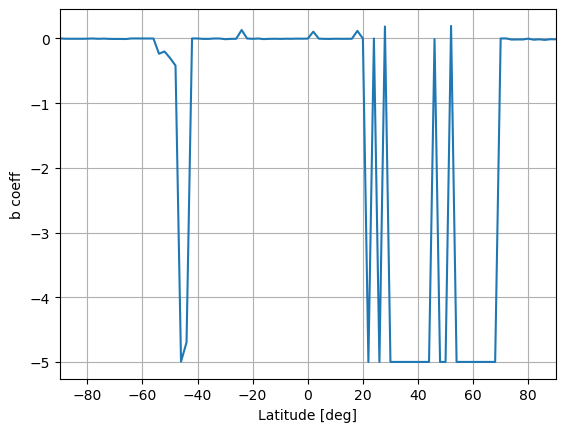

In [69]:
plt.plot(target_lat, b_coeffs)
plt.grid()
plt.xlim(-90, 90)
plt.xlabel('Latitude [deg]')
plt.ylabel('b coeff')

In [37]:
np.where(target_lat==-20)

(array([35]),)

In [27]:
anom_tend.shape

(16, 91)

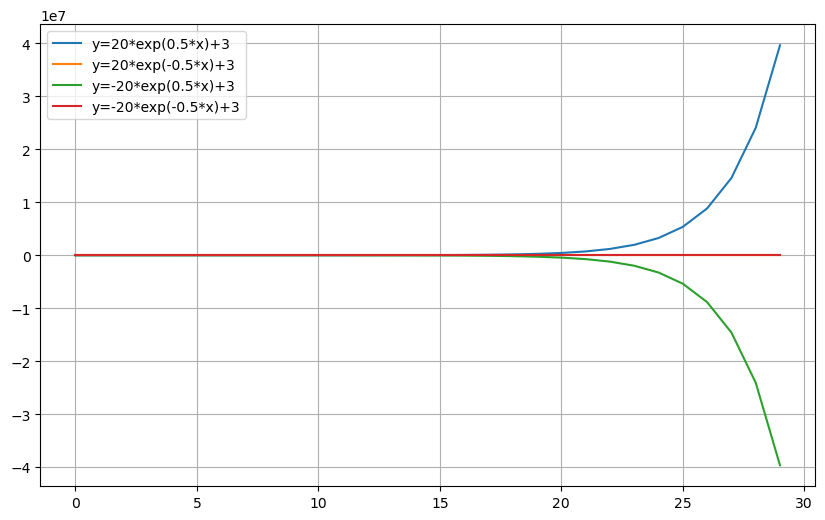

In [49]:
x = np.arange(0, 30)
a = 20
b = 0.5
c = 3

y_1 = a*np.exp(b*x)+c
y_2 = a*np.exp(-1*b*x)+c
y_3 = -a*np.exp(b*x)+c
y_4 = -a*np.exp(-1*b*x)+c

plt.figure(figsize=(10, 6))
plt.plot(x, y_1, label = f'y={a}*exp({b}*x)+{c}')
plt.plot(x, y_2, label = f'y={a}*exp(-{b}*x)+{c}')
plt.plot(x, y_3, label = f'y=-{a}*exp({b}*x)+{c}')
plt.plot(x, y_4, label = f'y=-{a}*exp(-{b}*x)+{c}')
plt.legend()
plt.grid()
plt.show()

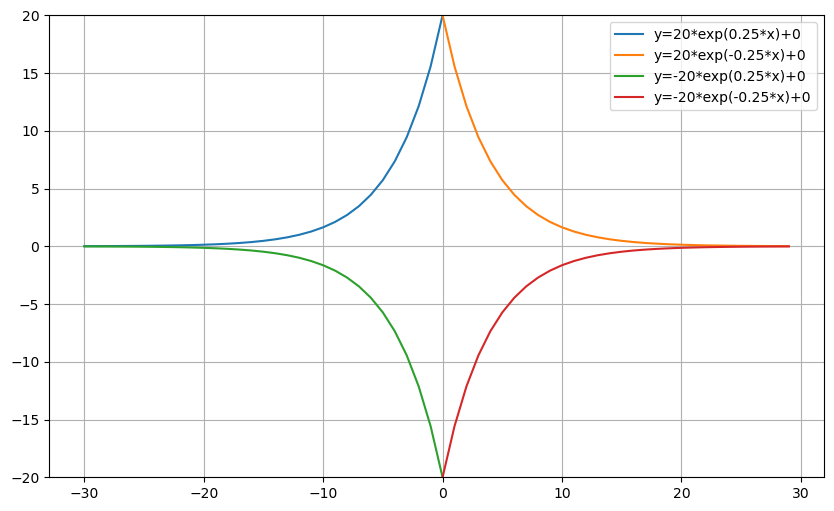

In [67]:
x = np.arange(-30, 30)
a = 20
b = 0.25
c = 0

y_1 = a*np.exp(b*x)+c
y_2 = a*np.exp(-b*x)+c
y_3 = -a*np.exp(b*x)+c
y_4 = -a*np.exp(-b*x)+c

plt.figure(figsize=(10, 6))   # <-- correct line
plt.plot(x, y_1, label=f'y={a}*exp({b}*x)+{c}')
plt.plot(x, y_2, label=f'y={a}*exp(-{b}*x)+{c}')
plt.plot(x, y_3, label=f'y=-{a}*exp({b}*x)+{c}')
plt.plot(x, y_4, label=f'y=-{a}*exp(-{b}*x)+{c}')
plt.legend()
plt.grid()
plt.ylim(-20, 20)
plt.show()


#### **4.2. IPSL-CM6A-LR**

#### **1. Regridding the OHT to the target latitude**

In [15]:
oht_ipsl = ocean_regr_vec(hfbasins_gl_exp_ipsl[:, :, :, 0], oc_lat_ipsl, target_lat)

#### **2. Turning the nan values to zeros for the latitudes with no OHT**

In [ ]:

#for i in range (2):
#    for j in range(900):
#        print(target_lat[np.where(np.isnan(oht_ipsl[i, j, :]))])

#for i in range(2):
#    for j in range(900):
#        print(target_lat[np.where(oht_ipsl[i, j, :] < -10)])
#        if np.any(oht_ipsl[i, j] < -10):
#            print(i, j)

In [40]:
#oht_ipsl = np.nan_to_num(oht_ipsl, nan=0)

#### **3. Calculating the Atm + OHT**

In [16]:
toa_sum_ipsl = atm_exp_ipsl+ oht_ipsl

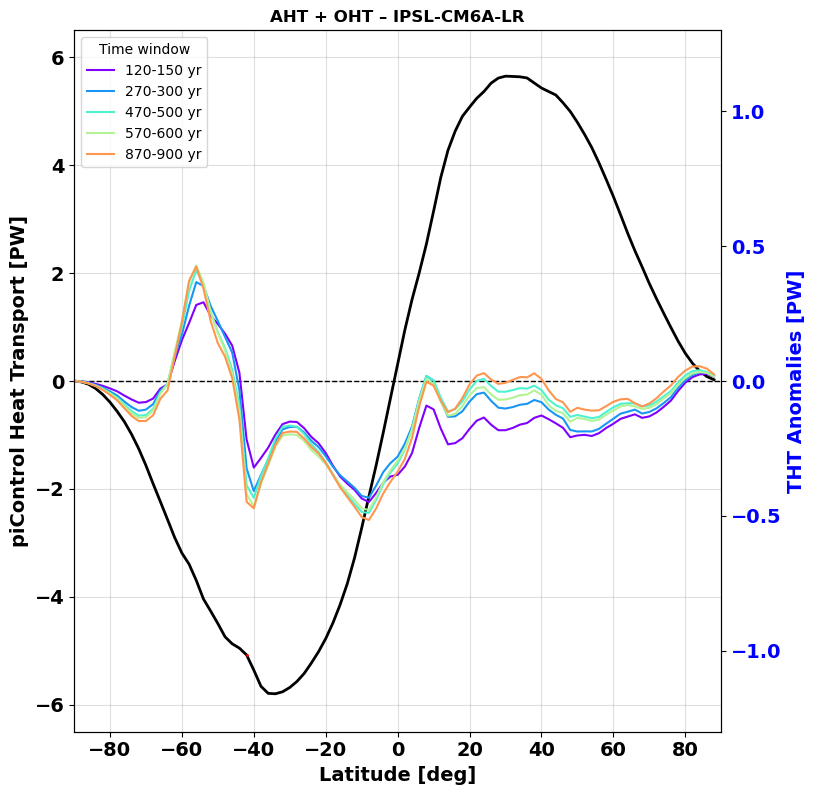

In [26]:
fig, ax1 = plt.subplots(figsize=(8, 8))

# --- Left axis (for control / baseline) ---
ax1.plot(target_lat, np.mean(toa_sum_ipsl[0, 21:51, :], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [deg]', fontsize=14, fontweight='bold')
ax1.set_ylabel('piControl Heat Transport [PW]', color='black', fontsize=14, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')

# --- Add zero line for ax1 ---
ax1.axhline(0, color='black', linestyle='--', linewidth=1)

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

time_windows = [(120, 150), (270, 300), (470, 500), (570, 600),
                (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows[0:-1], colors):
    anom = (np.mean(toa_sum_ipsl[1, start:end, :], axis=0)\
          - np.mean(toa_sum_ipsl[0, 21:51, :], axis=0))
    
    ax2.plot(target_lat, anom, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('THT Anomalies [PW]', color='blue', fontsize=14, fontweight='bold')
ax2.tick_params(axis='y', labelcolor='blue')

# --- Add zero line for ax2 ---
#ax2.axhline(0, color='blue', linestyle='--', linewidth=1)
ax1.plot(target_lat[24],
         np.mean(toa_sum_ipsl[0, 21:51, :], axis = 0)[24],
         'o',
         color='red',
         markersize=1,
         zorder=5)
# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.set_ylim(-6.5, 6.5)
ax2.set_ylim(-1.3, 1.3)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, title="Time window")

plt.title('AHT + OHT – IPSL-CM6A-LR', fontweight = 'bold')
plt.tight_layout()

# Make x-axis tick numbers stronger
ax1.tick_params(axis='x', labelsize=14)

# Left y-axis (piControl)
ax1.tick_params(axis='y', labelsize=14)

# Right y-axis (anomalies)
ax2.tick_params(axis='y', labelsize=14)

for label in ax1.get_xticklabels() + ax1.get_yticklabels():
    label.set_fontweight('bold')

for label in ax2.get_yticklabels():
    label.set_fontweight('bold')

plt.show()

In [18]:
np.nanmin(np.mean(toa_sum_ipsl[0, 21:51, :], axis = 0))

-5.796637116161253

In [24]:
np.where(target_lat==-42)

(array([24]),)

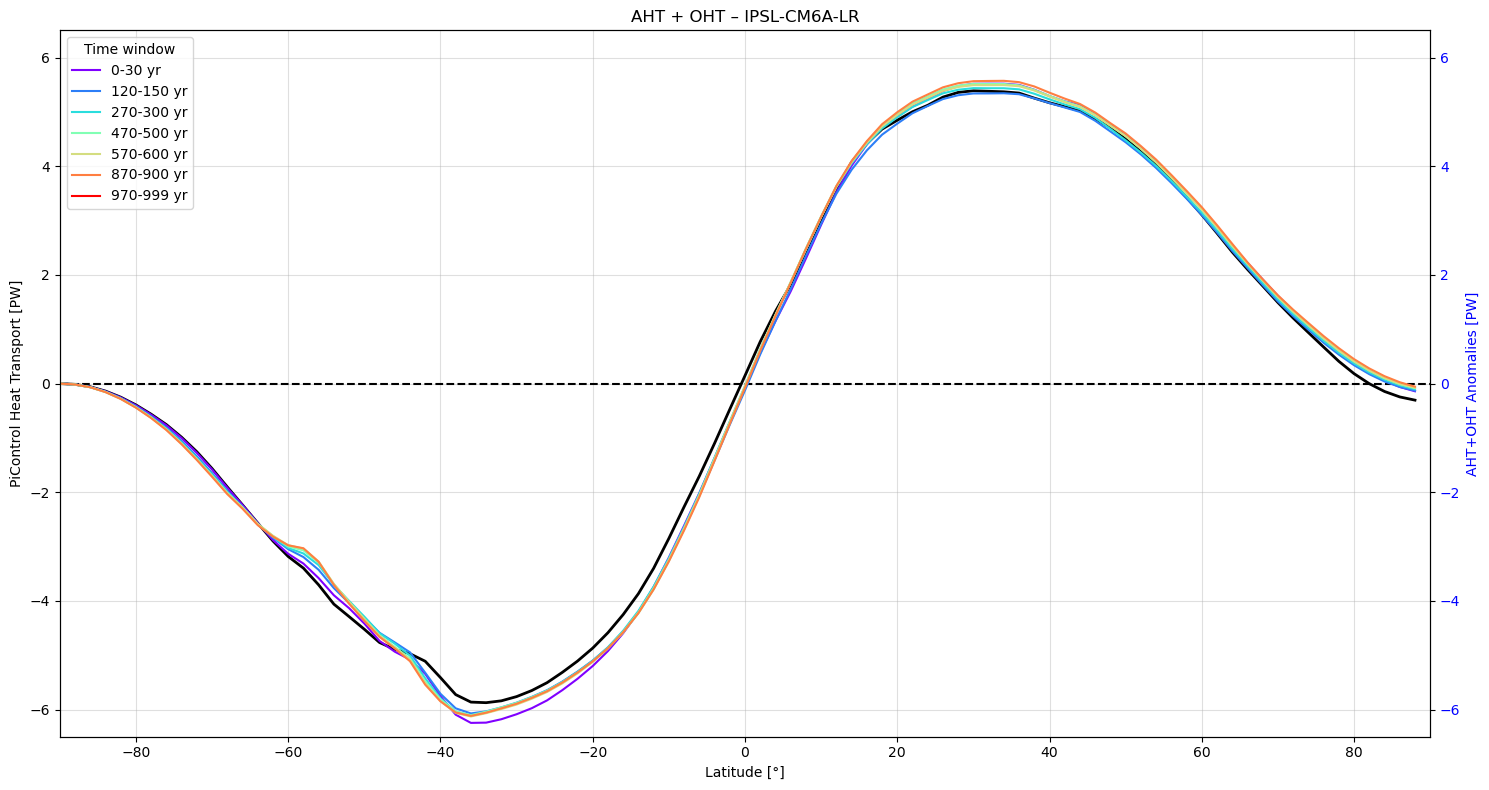

In [28]:
fig, ax1 = plt.subplots(figsize=(15, 8))

# --- Left axis (for control / baseline) ---
ax1.plot(target_lat, np.mean(toa_sum_ipsl[0, :, :], axis = 0), color='black', label='piControl', linewidth=2)
ax1.set_xlabel('Latitude [°]')
ax1.set_ylabel('PiControl Heat Transport [PW]', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# --- Right axis (for anomalies) ---
ax2 = ax1.twinx()

# Time windows for the anomalies
time_windows = [(0, 30), (120, 150), (270, 300), (470, 500), (570, 600), (870, 900), (970, 999)]
colors = plt.cm.rainbow(np.linspace(0, 1, len(time_windows)))

for (start, end), color in zip(time_windows, colors):
    x4 = (np.mean(toa_sum_ipsl[1, start:end, :], axis=0))
    
    ax2.plot(target_lat, x4, color=color, label=f'{start}-{end} yr')

ax2.set_ylabel('AHT+OHT Anomalies [PW]', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')
ax1.axhline(0, color='black', linestyle='--')
#ax2.axhline(0, color='blue', linestyle='--')
ax1.set_ylim(-6.5, 6.5)
ax2.set_ylim(-6.5, 6.5)
#ax2.set_ylim(-1.3, 1.3)

# --- Formatting ---
ax1.set_xlim(-90, 90)
ax1.grid(alpha=0.4)
ax2.legend(loc='upper left', fontsize=10, title="Time window")

plt.title('AHT + OHT – IPSL-CM6A-LR')
plt.tight_layout()
plt.show()